**Министерство науки и высшего образования Российской Федерации**

ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ ОБРАЗОВАТЕЛЬНОЕ
УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ

**НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ ИТМО**

**ITMO University**

# Лабораторная работа №2

### Численные методы в математическом анализе

**Авторы работы**

- Галстян Артём Артакович (465503)
- Сакулин Иван Михайлович (467335)
- Сафронов Иван Сергеевич (467380)

**Руководитель**

- Попов Арсений Михайлович



# Введение

**Цель работы.** Изучение и практическое освоение численных методов интерполяции, дифференцирования и интегрирования функций, а также оценка их точности и устойчивости при различных параметрах вычислительных схем. Проведение вычислительных экспериментов и сравнение полученных результатов с теоретическими оценками погрешностей.

**Задачи, выполняемые в процессе работы.**
- Реализация полиномиальной интерполяции по Лагранжу и сплайн-интерполяции.
- Исследование влияния числа узлов и типа сетки на точность интерполяции.
- Реализация численного дифференцирования первого и высших порядков.
- Исследование зависимости ошибки дифференцирования от шага сетки.
- Реализация основных методов численного интегрирования и их сравнение.
- Изучение метода Монте-Карло и оценки его сходимости.

In [1]:
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt

import sys
import math
import warnings
from collections import namedtuple
from typing import Callable, Union, List, Tuple
ScalarFunc = Callable[[float], float]

In [2]:
# Настройка шрифтов графиков
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'Liberation Sans', 'Bitstream Vera Sans', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'stixsans'
warnings.filterwarnings('ignore', message='findfont: Font family.*not found')
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')

# Интерполяция

### (1) Реализация интерполяции полиномами

In [3]:
def lagrange_interpolation(
    x_nodes: list[float],
    y_nodes: list[float],
    x_range: float|list[float]
    ) -> list[float]:
    """ Интерполяция по Лагранжу (значения в точке/точках x_range) """
    n = len(x_nodes)
    m = len(x_range) if hasattr(x_range, '__len__') else 1

    if m == 1:
        # Для одной точки x
        x = x_range
        y_interp = 0
        for i in range(n):
            term = y_nodes[i]
            for j in range(n):
                if j != i:
                    term *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
            y_interp += term
        return y_interp
    else:
        # Для массива точек x_range
        y_interp = np.zeros_like(x_range)
        for i in range(n):
            # Вычисляем i-й базисный полином
            basis = np.ones_like(x_range)
            for j in range(n):
                if j != i:
                    basis *= (x_range - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
            y_interp += y_nodes[i] * basis
        return y_interp

##### Генерация различных сеток

In [4]:
def generate_uniform_nodes(n: int, a=-1, b=1):
    """ Генерация равномерных узлов """
    return np.linspace(a, b, n)

def generate_chebyshev_nodes(n: int, a=-1, b=1):
    """ Генерация узлов Чебышева для уменьшения феномена Рунге """
    k = np.arange(1, n + 1)
    nodes = np.cos((2 * k - 1) * np.pi / (2 * n))
    # Масштабирование на интервал [a, b]
    nodes = a + (b - a) * (nodes + 1) / 2
    return nodes

##### Тестирование на точках

In [5]:
for n in [3, 5, 7]:
    x_uni = generate_uniform_nodes(n, 0, 2)
    y_uni = x_uni**2
    x_test_point = 1.3
    y_interp = lagrange_interpolation(x_uni, y_uni, x_test_point)
    exact = x_test_point**2
    error = abs(exact - y_interp)
    print(f"  n={n}: интерп.={y_interp:.6f}, точное={exact:.6f}, ошибка={error:.2e}")

  n=3: интерп.=1.690000, точное=1.690000, ошибка=2.22e-16
  n=5: интерп.=1.690000, точное=1.690000, ошибка=2.22e-16
  n=7: интерп.=1.690000, точное=1.690000, ошибка=2.22e-16


##### Тестирование для разного количества узлов

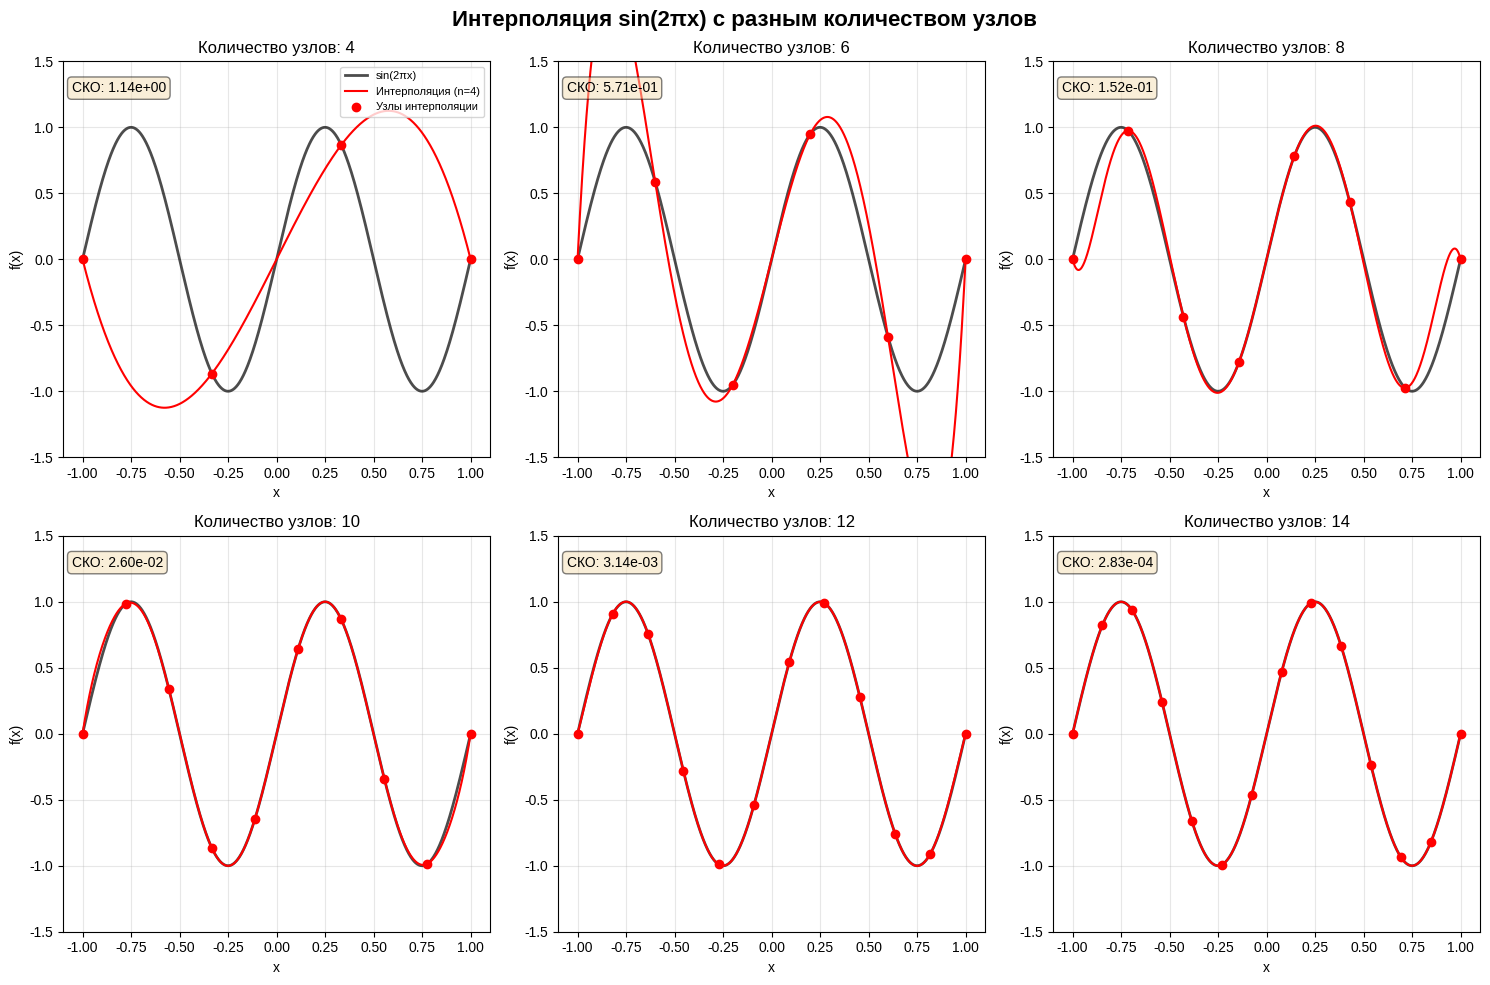

In [6]:
def sin_function(x):
    return np.sin(2 * np.pi * x)

fig2, axes2 = plt.subplots(2, 3, figsize=(15, 10))
fig2.suptitle('Интерполяция sin(2πx) с разным количеством узлов', fontsize=16, fontweight='bold')

node_counts = [4, 6, 8, 10, 12, 14]
x_fine_sin = np.linspace(-1, 1, 1000)
y_exact_sin = sin_function(x_fine_sin)

for idx, n in enumerate(node_counts):
    ax = axes2[idx // 3, idx % 3]

    # Равномерные узлы
    x_nodes = generate_uniform_nodes(n)
    y_nodes = sin_function(x_nodes)
    y_interp = lagrange_interpolation(x_nodes, y_nodes, x_fine_sin)

    # Построение графиков
    ax.plot(x_fine_sin, y_exact_sin, 'k-', linewidth=2, label='sin(2πx)', alpha=0.7)
    ax.plot(x_fine_sin, y_interp, 'r-', linewidth=1.5, label=f'Интерполяция (n={n})')
    ax.plot(x_nodes, y_nodes, 'ro', markersize=6, label='Узлы интерполяции')

    # Вычисление ошибки
    error = np.sqrt(np.mean((y_exact_sin - y_interp)**2))

    ax.text(0.02, 0.95, f'СКО: {error:.2e}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'Количество узлов: {n}')
    ax.set_ylim(-1.5, 1.5)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()

##### Тестирование для разных сеток

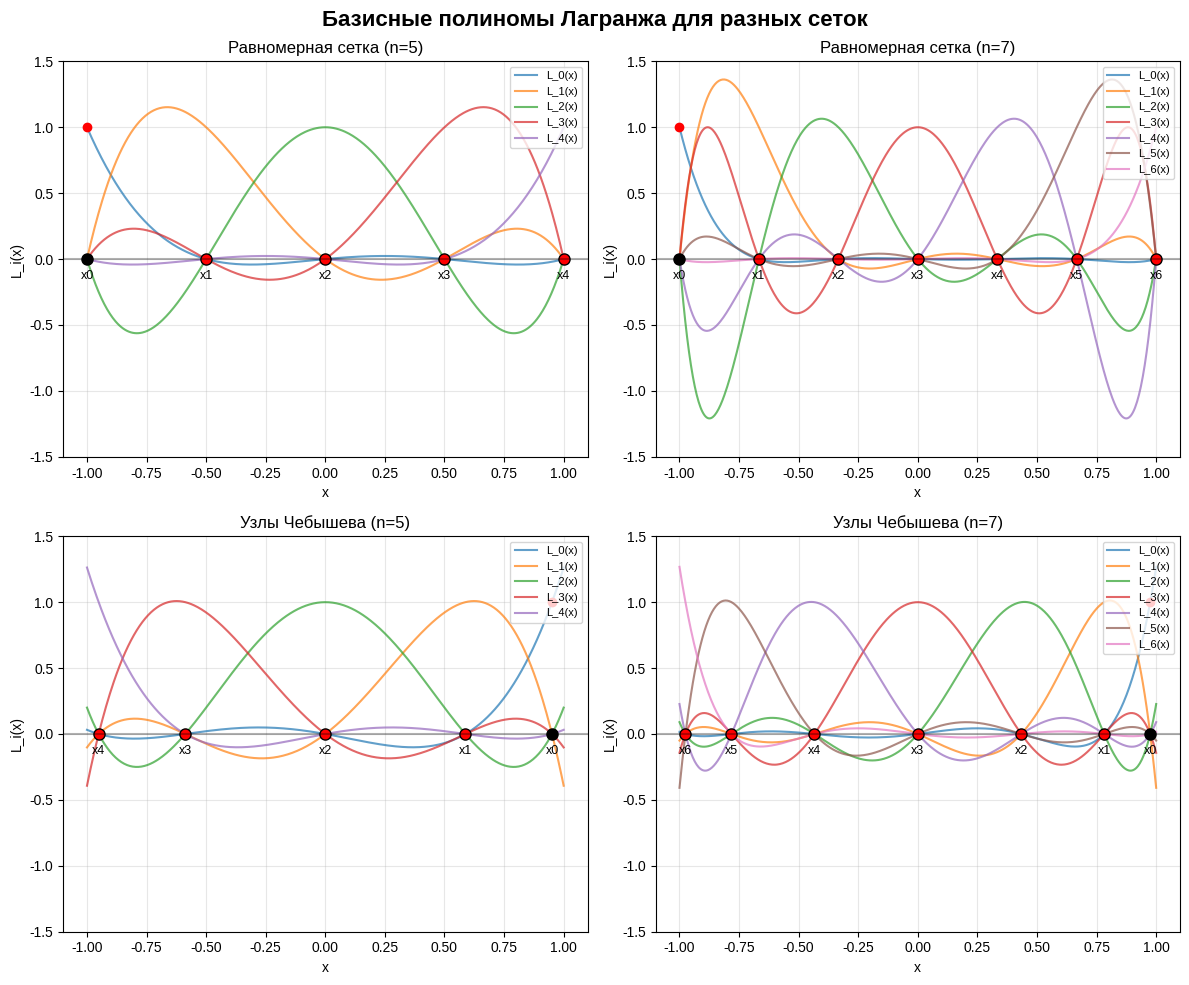

In [7]:
fig3, axes3 = plt.subplots(2, 2, figsize=(12, 10))
fig3.suptitle('Базисные полиномы Лагранжа для разных сеток', fontsize=16, fontweight='bold')

# Разные сетки узлов
grid_configs = [
    (generate_uniform_nodes(5), 'Равномерная сетка (n=5)'),
    (generate_uniform_nodes(7), 'Равномерная сетка (n=7)'),
    (generate_chebyshev_nodes(5), 'Узлы Чебышева (n=5)'),
    (generate_chebyshev_nodes(7), 'Узлы Чебышева (n=7)')
]

for idx, (x_nodes, title) in enumerate(grid_configs):
    ax = axes3[idx // 2, idx % 2]
    n = len(x_nodes)
    x_plot = np.linspace(-1, 1, 500)

    # Вычисляем все базисные полиномы
    basis_polys = []
    for i in range(n):
        # Создаем y-вектор: 1 в i-м узле, 0 в остальных
        y_basis = np.zeros(n)
        y_basis[i] = 1
        # Вычисляем базисный полином
        basis_i = lagrange_interpolation(x_nodes, y_basis, x_plot)
        basis_polys.append(basis_i)

        # Рисуем базисный полином
        ax.plot(x_plot, basis_i, linewidth=1.5, alpha=0.7, label=f'L_{i}(x)')

    # Отмечаем узлы
    for i, x_node in enumerate(x_nodes):
        ax.plot(x_node, 0, 'ko', markersize=8)
        ax.plot(x_node, 1 if i == 0 else 0, 'ro', markersize=6)
        ax.text(x_node, -0.15, f'x{i}', ha='center', fontsize=9)

    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('L_i(x)')
    ax.set_title(title)
    ax.set_ylim(-1.5, 1.5)
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()

### (2) Исследование ошибки интерполяции для $f(x) = e^{-x^2} \cdot\sin{2πx}$

##### Реализация

In [8]:
def smooth_function(x):
    """ f(x) = exp(-x²) * sin(2πx) """
    return np.exp(-x**2) * np.sin(2 * np.pi * x)

def compute_realistic_M_n(n: int) -> float:
    """ Оценка верхней границы для модуля n-й производной функции """

    # Предопределенные значения M_n для n = 0..11
    predefined_values = [
        1.0, 12.0, 70.0, 400.0, 2500.0, 15000.0, 100000.0,
        700000.0, 5000000.0, 35000000.0, 250000000.0, 1800000000.0
    ]

    if n < len(predefined_values):
        return predefined_values[n]
    else:
        # Для n > 11 продолжаем экспоненциальный рост
        last_index = len(predefined_values) - 1
        last_value = predefined_values[last_index]
        # Умножаем на 3.8 каждый следующий n
        return last_value * (3.8 ** (n - last_index))

def compute_omega_max(x_nodes: list, interval: tuple[float, float]) -> float:
    """ Вычисление максимального значения |ω_n(x)| на интервале
        ω_n(x) = П(x - x_k) — узловой многочлен """

    x_test = np.linspace(interval[0], interval[1], 2000)

    omega = np.ones_like(x_test)
    for xk in x_nodes:
        omega *= (x_test - xk)

    return np.max(np.abs(omega))

def verify_interpolation_accuracy(x_nodes: list, y_nodes: list):
    """ Отклонение интерполяции от реальных значений в узлах """
    y_interp_nodes = lagrange_interpolation(x_nodes, y_nodes, x_nodes)
    max_error = np.max(np.abs(y_interp_nodes - y_nodes))
    return max_error

def analyze_interpolation_error():
    """ Анализ ошибки интерполяции для гладкой функции """

    print("АНАЛИЗ ОШИБКИ ИНТЕРПОЛЯЦИИ ГЛАДКОЙ ФУНКЦИИ")

    interval = (-1, 1)
    x_fine = np.linspace(interval[0], interval[1], 2000)
    y_true = smooth_function(x_fine)

    # Значения n (степени полинома)
    n_values = list(range(1, 11))

    errors_actual = []
    errors_theoretical = []
    max_omega_values = []
    M_values = []

    print(f"\n{'n':>3} | {'Узлы':>6} | {'Факт. ошибка':>12} | {'Теор. оценка':>12} | "
          f"{'Отношение':>10} | {'max|ω_n|':>10} | {'M_n+1':>10}")
    print("-"*105)

    for n in n_values:
        # Число узлов = n + 1
        num_nodes = n + 1
        x_nodes = np.linspace(interval[0], interval[1], num_nodes)
        y_nodes = smooth_function(x_nodes)

        # Проверяем точность интерполяции в узлах
        node_error = verify_interpolation_accuracy(x_nodes, y_nodes)
        if node_error > 1e-10:
            print(f"\nВНИМАНИЕ: большая ошибка в узлах для n={n}: {node_error:.2e}")

        # Интерполяция на всей сетке
        y_interp = lagrange_interpolation(x_nodes, y_nodes, x_fine)

        # Фактическая ошибка
        error_actual = np.max(np.abs(y_true - y_interp))
        errors_actual.append(error_actual)

        # Вычисляем max|ω_n(x)|
        max_omega = compute_omega_max(x_nodes, interval)
        max_omega_values.append(max_omega)

        # Оцениваем M_{n+1}
        M_n1 = compute_realistic_M_n(n + 1)
        M_values.append(M_n1)

        # Теоретическая оценка: |f(x)-P_n(x)| ≤ M_{n+1}/(n+1)! * max|ω_n(x)|
        error_bound = M_n1 * max_omega / math.factorial(n + 1)
        errors_theoretical.append(error_bound)

        ratio = error_actual / error_bound

        print(f"{n:3} | {num_nodes:6} | {error_actual:12.2e} | {error_bound:12.2e} | "
              f"{ratio:10.4f} | {max_omega:10.2e} | {M_n1:10.2e}")

    # Анализ сходимости
    # print("\nАНАЛИЗ СХОДИМОСТИ:")
    # for i in range(1, len(errors_actual)):
    #     n_prev, n_curr = n_values[i-1], n_values[i]
    #     error_prev, error_curr = errors_actual[i-1], errors_actual[i]

    #     if error_curr < error_prev:
    #         improvement = error_prev / error_curr
    #         print(f"  n={n_prev}→{n_curr}: ошибка уменьшилась в {improvement:.2f} раз")
    #     else:
    #         deterioration = error_curr / error_prev
    #         print(f"  n={n_prev}→{n_curr}: ошибка УВЕЛИЧИЛАСЬ в {deterioration:.2f} раз")

    # Визуализация
    plt.figure(figsize=(14, 10))

    # График 1: Ошибки
    plt.subplot(2, 2, 1)
    plt.semilogy(n_values, errors_actual, 'bo-', label='Фактическая',
                linewidth=2, markersize=8)
    plt.semilogy(n_values, errors_theoretical, 'r--', label='Теоретическая',
                linewidth=2)
    plt.xlabel('Степень полинома n')
    plt.ylabel('Максимальная ошибка')
    plt.title('Зависимость ошибки от степени полинома')
    plt.grid(True, alpha=0.3, which='both')
    plt.legend()

    # График 2: Примеры интерполяции
    plt.subplot(2, 2, 2)
    plt.plot(x_fine, y_true, 'k-', label='Точная функция', linewidth=2, alpha=0.7)

    # Покажем для n=3, 6, 9
    for n, color, style in [(3, 'r', '--'), (6, 'g', '-.'), (9, 'b', ':')]:
        num_nodes = n + 1
        x_nodes = np.linspace(interval[0], interval[1], num_nodes)
        y_nodes = smooth_function(x_nodes)
        y_interp = lagrange_interpolation(x_nodes, y_nodes, x_fine)
        plt.plot(x_fine, y_interp, color=color, linestyle=style,
                label=f'n={n} (ошибка={errors_actual[n-1]:.2e})', linewidth=1.5)
        plt.scatter(x_nodes, y_nodes, color=color, s=30, alpha=0.7)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Примеры интерполяции для разных n')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # График 3: Отношение факт/теор
    plt.subplot(2, 2, 3)
    ratios = [a/t for a, t in zip(errors_actual, errors_theoretical)]
    plt.plot(n_values, ratios, 'g-o', linewidth=2, markersize=8)
    plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Граница')
    plt.fill_between(n_values, 0, 1, alpha=0.2, color='green',
                    label='Корректная область')
    plt.xlabel('Степень полинома n')
    plt.ylabel('Отношение: факт/теор')
    plt.title('Качество теоретической оценки (должно быть ≤ 1)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # График 4: Рост M_{n+1} и (n+1)!
    plt.subplot(2, 2, 4)

    ax1 = plt.gca()
    ax1.semilogy(n_values, M_values, 'b-o', label='M_{n+1}',
                linewidth=2, markersize=6)
    ax1.set_xlabel('Степень полинома n')
    ax1.set_ylabel('M_{n+1}', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(True, alpha=0.3, which='both')

    ax2 = ax1.twinx()
    fact_values = [math.factorial(k+1) for k in n_values]
    ax2.semilogy(n_values, fact_values, 'r--s', label='(n+1)!',
                linewidth=2, markersize=6)
    ax2.set_ylabel('(n+1)!', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.title('Рост M_{n+1} и (n+1)!')

    plt.tight_layout()
    plt.show()

    return errors_actual, errors_theoretical, n_values

##### Запуск

АНАЛИЗ ОШИБКИ ИНТЕРПОЛЯЦИИ ГЛАДКОЙ ФУНКЦИИ

  n |   Узлы | Факт. ошибка | Теор. оценка |  Отношение |   max|ω_n| |      M_n+1
---------------------------------------------------------------------------------------------------------
  1 |      2 |     9.42e-01 |     3.50e+01 |     0.0269 |   1.00e+00 |   7.00e+01
  2 |      3 |     9.42e-01 |     2.57e+01 |     0.0367 |   3.85e-01 |   4.00e+02
  3 |      4 |     1.53e+00 |     2.06e+01 |     0.0742 |   1.98e-01 |   2.50e+03
  4 |      5 |     9.42e-01 |     1.42e+01 |     0.0664 |   1.13e-01 |   1.50e+04
  5 |      6 |     1.42e+00 |     9.61e+00 |     0.1476 |   6.92e-02 |   1.00e+05
  6 |      7 |     7.92e-01 |     6.09e+00 |     0.1301 |   4.38e-02 |   7.00e+05
  7 |      8 |     7.98e-01 |     3.53e+00 |     0.2264 |   2.84e-02 |   5.00e+06
  8 |      9 |     4.95e-01 |     1.81e+00 |     0.2732 |   1.88e-02 |   3.50e+07
  9 |     10 |     3.01e-01 |     8.68e-01 |     0.3468 |   1.26e-02 |   2.50e+08
 10 |     11 |     1.96e-01 | 

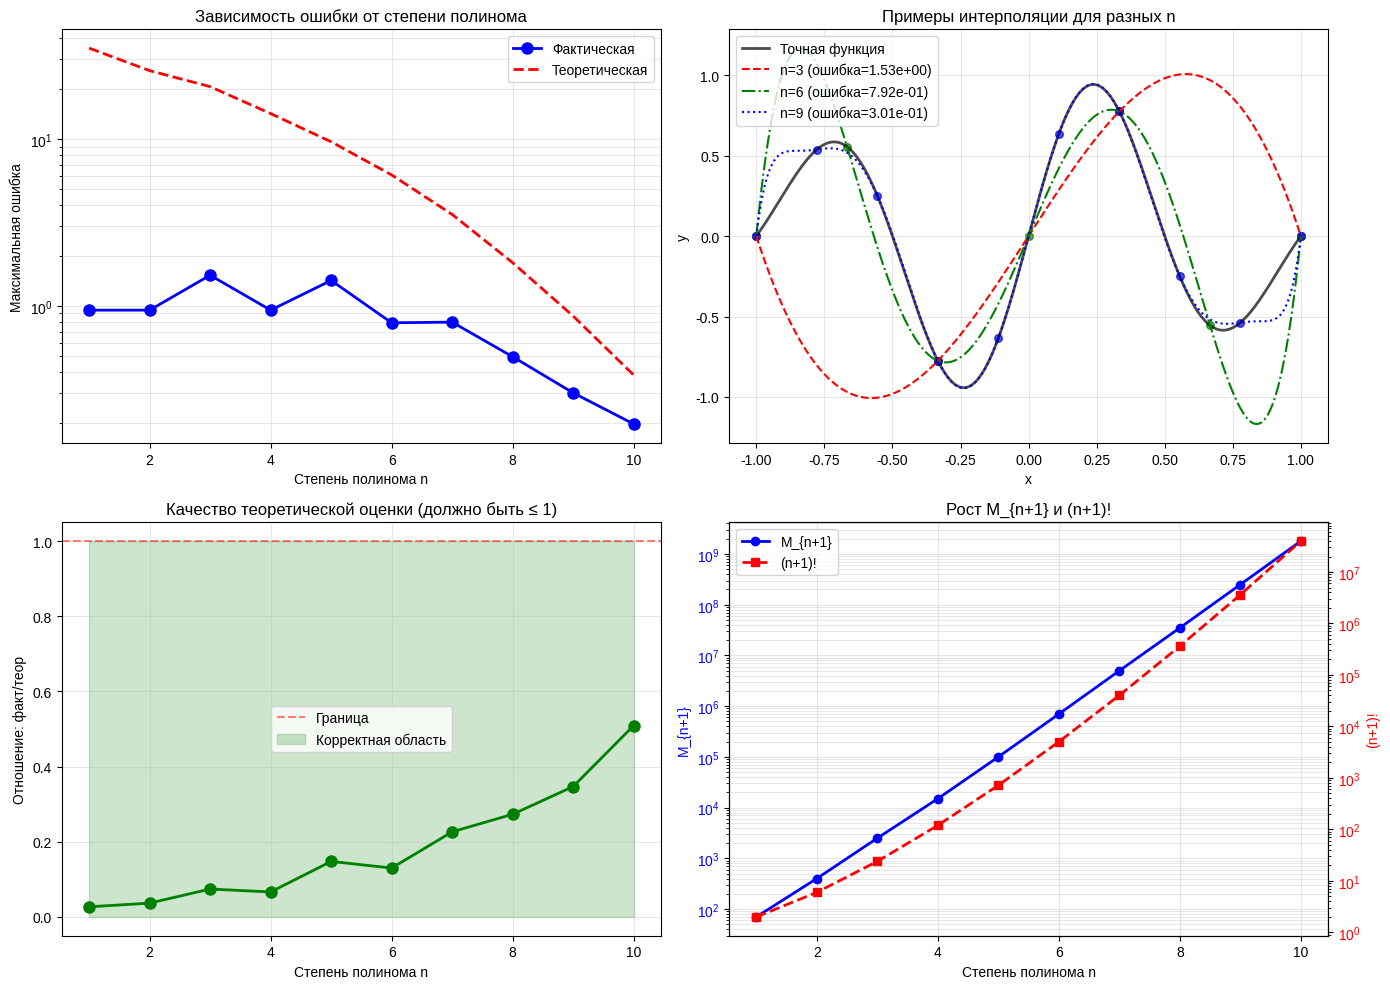

In [9]:
errors_actual, errors_theoretical, n_values = analyze_interpolation_error()

### (3) Поведение интерполяции для $f(x) = \frac{1}{1+x^2}$ (функция Рунге)

##### Реализация

In [10]:
def runge_function(x):
    """ f(x) = 1/(1 + x²) - функция Рунге """
    return 1 / (1 + x**2)

def analyze_runge_phenomenon():
    """ Анализ эффекта Рунге для функции f(x) = 1/(1 + x²) на [-5, 5] """
    interval = (-5, 5)

    print("ИССЛЕДОВАНИЕ ЭФФЕКТА РУНГЕ")
    print("Функция: f(x) = 1/(1 + x²)")
    print(f"Интервал: [{interval[0]}, {interval[1]}]")

    # Подготовка данных
    x_fine = np.linspace(interval[0], interval[1], 1000)
    y_true = runge_function(x_fine)

    # Исходная функция
    # plt.figure(figsize=(8, 5))
    # plt.plot(x_fine, y_true, 'k-', linewidth=2)
    # plt.title('Исходная функция $f(x) = 1/(1+x^2)$')
    # plt.xlabel('x')
    # plt.ylabel('f(x)')
    # plt.grid(True, alpha=0.3)
    # plt.xlim(interval)
    # plt.ylim([0, 1.1])
    # plt.tight_layout()
    # plt.show()

    # Демонстрация эффекта для разных n
    n_values = [5, 10, 15, 20]

    # Создаем новую фигуру для 4 графиков
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    max_errors = []

    for idx, n in enumerate(n_values):
        ax = axes[idx]  # Используем оси по порядку

        # Равномерные узлы
        x_nodes = np.linspace(interval[0], interval[1], n)
        y_nodes = runge_function(x_nodes)

        # Интерполяция с помощью ВАШЕЙ функции
        y_interp = lagrange_interpolation(x_nodes, y_nodes, x_fine)

        # Ошибка
        error = np.abs(y_true - y_interp)
        max_error = np.max(error)
        max_errors.append(max_error)

        # График
        ax.plot(x_fine, y_true, 'k-', label='Исходная', linewidth=2, alpha=0.7)
        ax.plot(x_fine, y_interp, 'r-', label='Интерполяция', linewidth=1.5, alpha=0.7)
        ax.scatter(x_nodes, y_nodes, color='blue', s=20, alpha=0.7, label='Узлы')

        # Подсветим области больших ошибок
        ax.fill_between(x_fine, 0, error, alpha=0.1, color='red')

        ax.set_title(f'n = {n} равномерных узлов\nМакс. ошибка = {max_error:.3f}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')
        ax.set_xlim(interval)
        ax.set_ylim([-2, 2])  # Оставляем место для осцилляций

    plt.suptitle('Эффект Рунге: интерполяция $f(x) = 1/(1+x^2)$ равномерными узлами',
                fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # Анализ роста ошибки
    print("\nАНАЛИЗ РОСТА ОШИБКИ:")
    print(f"{'n':>5} {'Макс. ошибка':>15} {'Ошибка на x=5':>15} {'Рост':>10}")

    for i, n in enumerate(n_values):
        x_nodes = np.linspace(interval[0], interval[1], n)
        y_nodes = runge_function(x_nodes)
        y_interp_at_5 = lagrange_interpolation(x_nodes, y_nodes, 5.0)
        error_at_5 = abs(runge_function(5.0) - y_interp_at_5)

        if i > 0:
            growth = max_errors[i] / max_errors[i-1]
            print(f"{n:5} {max_errors[i]:15.6f} {error_at_5:15.6f} {growth:10.2f}x")
        else:
            print(f"{n:5} {max_errors[i]:15.6f} {error_at_5:15.6f} {'-':>10}")

    return max_errors, n_values

def error_growing():
    """ График зависимости ошибки от n (для большего диапазона) """

    interval = (-5, 5)

    print("Рост ошибки при увеличении числа узлов")
    print("Функция: f(x) = 1/(1 + x²)")
    print(f"Интервал: [{interval[0]}, {interval[1]}]")

    # Подготовка данных
    x_fine = np.linspace(interval[0], interval[1], 1000)
    y_true = runge_function(x_fine)

    plt.figure(figsize=(10, 6))

    n_test_values = list(range(5, 26, 2))  # От 5 до 25 с шагом 2
    errors_test = []

    for n in n_test_values:
        x_nodes = np.linspace(interval[0], interval[1], n)
        y_nodes = runge_function(x_nodes)
        y_interp = lagrange_interpolation(x_nodes, y_nodes, x_fine)
        max_error = np.max(np.abs(y_true - y_interp))
        errors_test.append(max_error)

    plt.plot(n_test_values, errors_test, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Число равномерных узлов (n)', fontsize=12)
    plt.ylabel('Максимальная ошибка интерполяции', fontsize=12)
    plt.title('Рост ошибки при увеличении числа узлов (эффект Рунге)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.tight_layout()
    plt.show()


def compare_with_chebyshev():
    """ Сравнение равномерных узлов и узлов Чебышева """

    interval = (-5, 5)
    n = 15

    x_fine = np.linspace(interval[0], interval[1], 500)
    y_true = runge_function(x_fine)

    # Равномерные узлы
    x_uniform = np.linspace(interval[0], interval[1], n)
    y_uniform = runge_function(x_uniform)

    # Узлы Чебышева (масштабированные на [-5,5])
    k = np.arange(n)
    x_chebyshev = 5 * np.cos((2*k + 1) * np.pi / (2*n))
    y_chebyshev = runge_function(x_chebyshev)

    # Интерполяция с помощью ВАШЕЙ функции
    y_interp_uniform = lagrange_interpolation(x_uniform, y_uniform, x_fine)
    y_interp_chebyshev = lagrange_interpolation(x_chebyshev, y_chebyshev, x_fine)

    # Ошибки
    error_uniform = np.abs(y_true - y_interp_uniform)
    error_chebyshev = np.abs(y_true - y_interp_chebyshev)

    # График сравнения
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Равномерные узлы
    ax1.plot(x_fine, y_true, 'k-', label='Исходная', linewidth=2)
    ax1.plot(x_fine, y_interp_uniform, 'r--', label='Интерполяция', linewidth=1.5)
    ax1.scatter(x_uniform, y_uniform, color='blue', s=50, label='Узлы')
    ax1.fill_between(x_fine, 0, error_uniform, alpha=0.1, color='red')
    ax1.set_title(f'Равномерные узлы (n={n})\nМакс. ошибка = {np.max(error_uniform):.4f}')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_ylim([-0.5, 1.5])

    # Узлы Чебышева
    ax2.plot(x_fine, y_true, 'k-', label='Исходная', linewidth=2)
    ax2.plot(x_fine, y_interp_chebyshev, 'g--', label='Интерполяция', linewidth=1.5)
    ax2.scatter(x_chebyshev, y_chebyshev, color='purple', s=50, label='Узлы Чебышева')
    ax2.fill_between(x_fine, 0, error_chebyshev, alpha=0.1, color='green')
    ax2.set_title(f'Узлы Чебышева (n={n})\nМакс. ошибка = {np.max(error_chebyshev):.4f}')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_ylim([-0.5, 1.5])

    plt.suptitle('Сравнение: Равномерные узлы vs Узлы Чебышева', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Вывод результатов
    print("\nСРАВНЕНИЕ С УЗЛАМИ ЧЕБЫШЕВА (n = 15)\n")
    print(f"Равномерные узлы:    макс. ошибка = {np.max(error_uniform):.6f}")
    print(f"Узлы Чебышева:       макс. ошибка = {np.max(error_chebyshev):.6f}")
    print(f"Улучшение в {np.max(error_uniform)/np.max(error_chebyshev):.1f} раз!")

    return np.max(error_uniform), np.max(error_chebyshev)

##### Анализ эффекта Рунге

ИССЛЕДОВАНИЕ ЭФФЕКТА РУНГЕ
Функция: f(x) = 1/(1 + x²)
Интервал: [-5, 5]


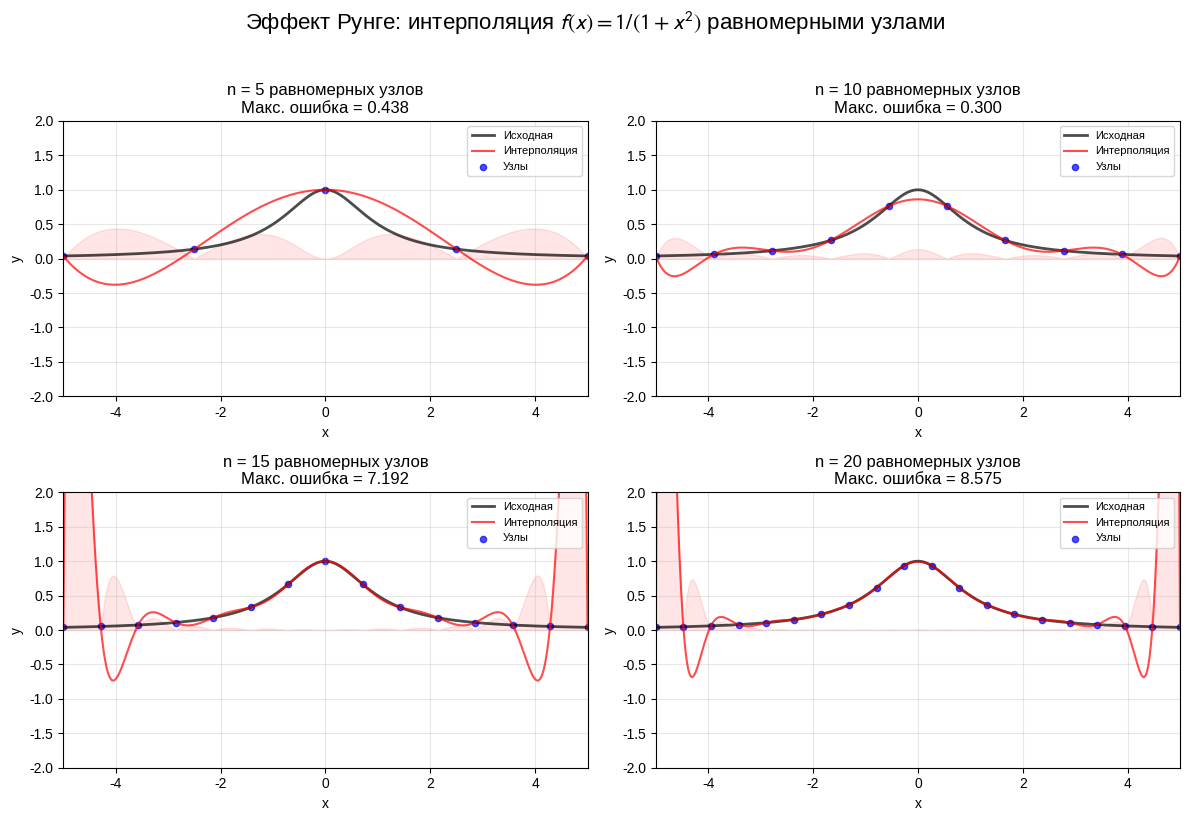


АНАЛИЗ РОСТА ОШИБКИ:
    n    Макс. ошибка   Ошибка на x=5       Рост
    5        0.438350        0.000000          -
   10        0.300285        0.000000       0.69x
   15        7.192324        0.000000      23.95x
   20        8.575361        0.000000       1.19x


In [11]:
max_errors, n_values = analyze_runge_phenomenon()

##### Рост ошибки при увеличении числа узлов

Рост ошибки при увеличении числа узлов
Функция: f(x) = 1/(1 + x²)
Интервал: [-5, 5]


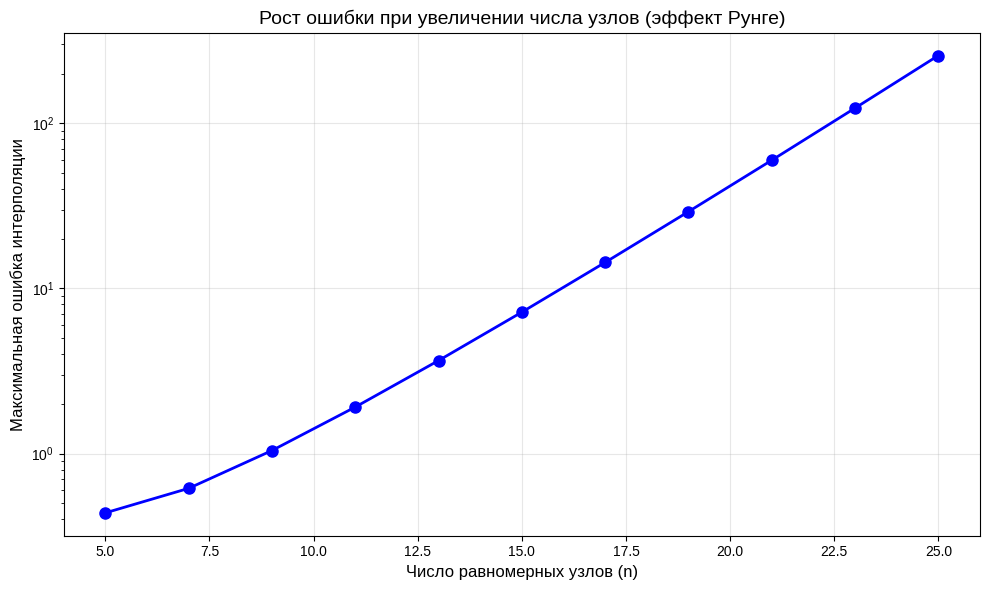

In [12]:
error_growing()

##### Сравнение с узлами Чебышева

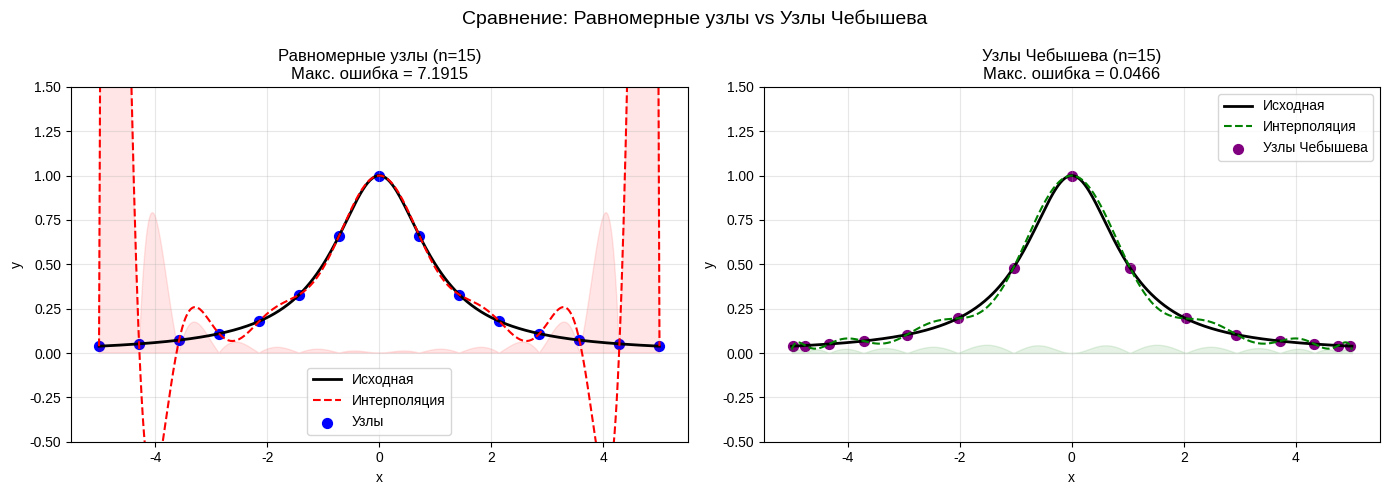


СРАВНЕНИЕ С УЗЛАМИ ЧЕБЫШЕВА (n = 15)

Равномерные узлы:    макс. ошибка = 7.191540
Узлы Чебышева:       макс. ошибка = 0.046594
Улучшение в 154.3 раз!


In [13]:
error_uniform, error_chebyshev = compare_with_chebyshev()

Почему узлы Чебышева лучше:
1. Минимизируют max|ω_n(x)| на интервале
2. Узлы сгущаются на краях, где функция меняется быстрее
3. Гарантируют сходимость интерполяции для гладких функций

### (1) Реализация интерполяции сплайнами

In [14]:
class CubicSpline:
    def __init__(self, x, y, bc_type='natural', yp_left=None, yp_right=None):
        # Сортируем узлы
        idx = np.argsort(x)
        self.x = np.array(x)[idx]
        self.y = np.array(y)[idx]
        self.n = len(x) - 1
        self.bc_type = bc_type

        # Вычисляем коэффициенты
        self._compute_coefficients(yp_left, yp_right)

    def _compute_coefficients(self, yp_left, yp_right):
        n = self.n
        x = self.x
        y = self.y

        # Шаги между узлами
        h = np.diff(x)

        # Создаем трехдиагональную систему для вторых производных M
        A = np.zeros((n+1, n+1))
        b = np.zeros(n+1)

        # Внутренние уравнения (i=1,...,n-1)
        for i in range(1, n):
            A[i, i-1] = h[i-1]
            A[i, i] = 2 * (h[i-1] + h[i])
            A[i, i+1] = h[i]
            b[i] = 3 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

        # Граничные условия
        if self.bc_type == 'natural':
            # S''(a) = S''(b) = 0
            A[0, 0] = 1
            b[0] = 0
            A[n, n] = 1
            b[n] = 0

        elif self.bc_type == 'clamped':
            # S'(a) = yp_left, S'(b) = yp_right
            if yp_left is None or yp_right is None:
                raise ValueError("Для clamped условий нужны yp_left и yp_right")

            A[0, 0] = 2 * h[0]
            A[0, 1] = h[0]
            b[0] = 3 * ((y[1] - y[0]) / h[0] - yp_left)

            A[n, n-1] = h[n-1]
            A[n, n] = 2 * h[n-1]
            b[n] = 3 * (yp_right - (y[n] - y[n-1]) / h[n-1])

        elif self.bc_type == 'not-a-knot':
            # S'''(x) непрерывна в x1 и x_{n-1}
            A[0, 0] = h[1]
            A[0, 1] = -(h[0] + h[1])
            A[0, 2] = h[0]
            b[0] = 0

            A[n, n-2] = h[n-1]
            A[n, n-1] = -(h[n-2] + h[n-1])
            A[n, n] = h[n-2]
            b[n] = 0

        # Решаем систему для M (вторых производных в узлах)
        self.M = np.linalg.solve(A, b)

        # Вычисляем коэффициенты сплайнов на каждом интервале
        self.a = y[:-1]  # свободные члены
        self.b = (y[1:] - y[:-1]) / h - h * (2*self.M[:-1] + self.M[1:]) / 3
        self.c = self.M[:-1]
        self.d = (self.M[1:] - self.M[:-1]) / (3 * h)

    def __call__(self, x_eval):
        """Вычисление сплайна в точках x_eval"""
        x_eval = np.asarray(x_eval)
        result = np.zeros_like(x_eval)

        # Для каждой точки находим соответствующий интервал
        for i in range(self.n):
            mask = (self.x[i] <= x_eval) & (x_eval <= self.x[i+1])
            if np.any(mask):
                dx = x_eval[mask] - self.x[i]
                # Кубический полином: a + b*dx + c*dx^2 + d*dx^3
                result[mask] = (self.a[i] +
                               self.b[i] * dx +
                               self.c[i] * dx**2 +
                               self.d[i] * dx**3)

        return result

### (2) Оценка зависимости интерполяции от граничных условий

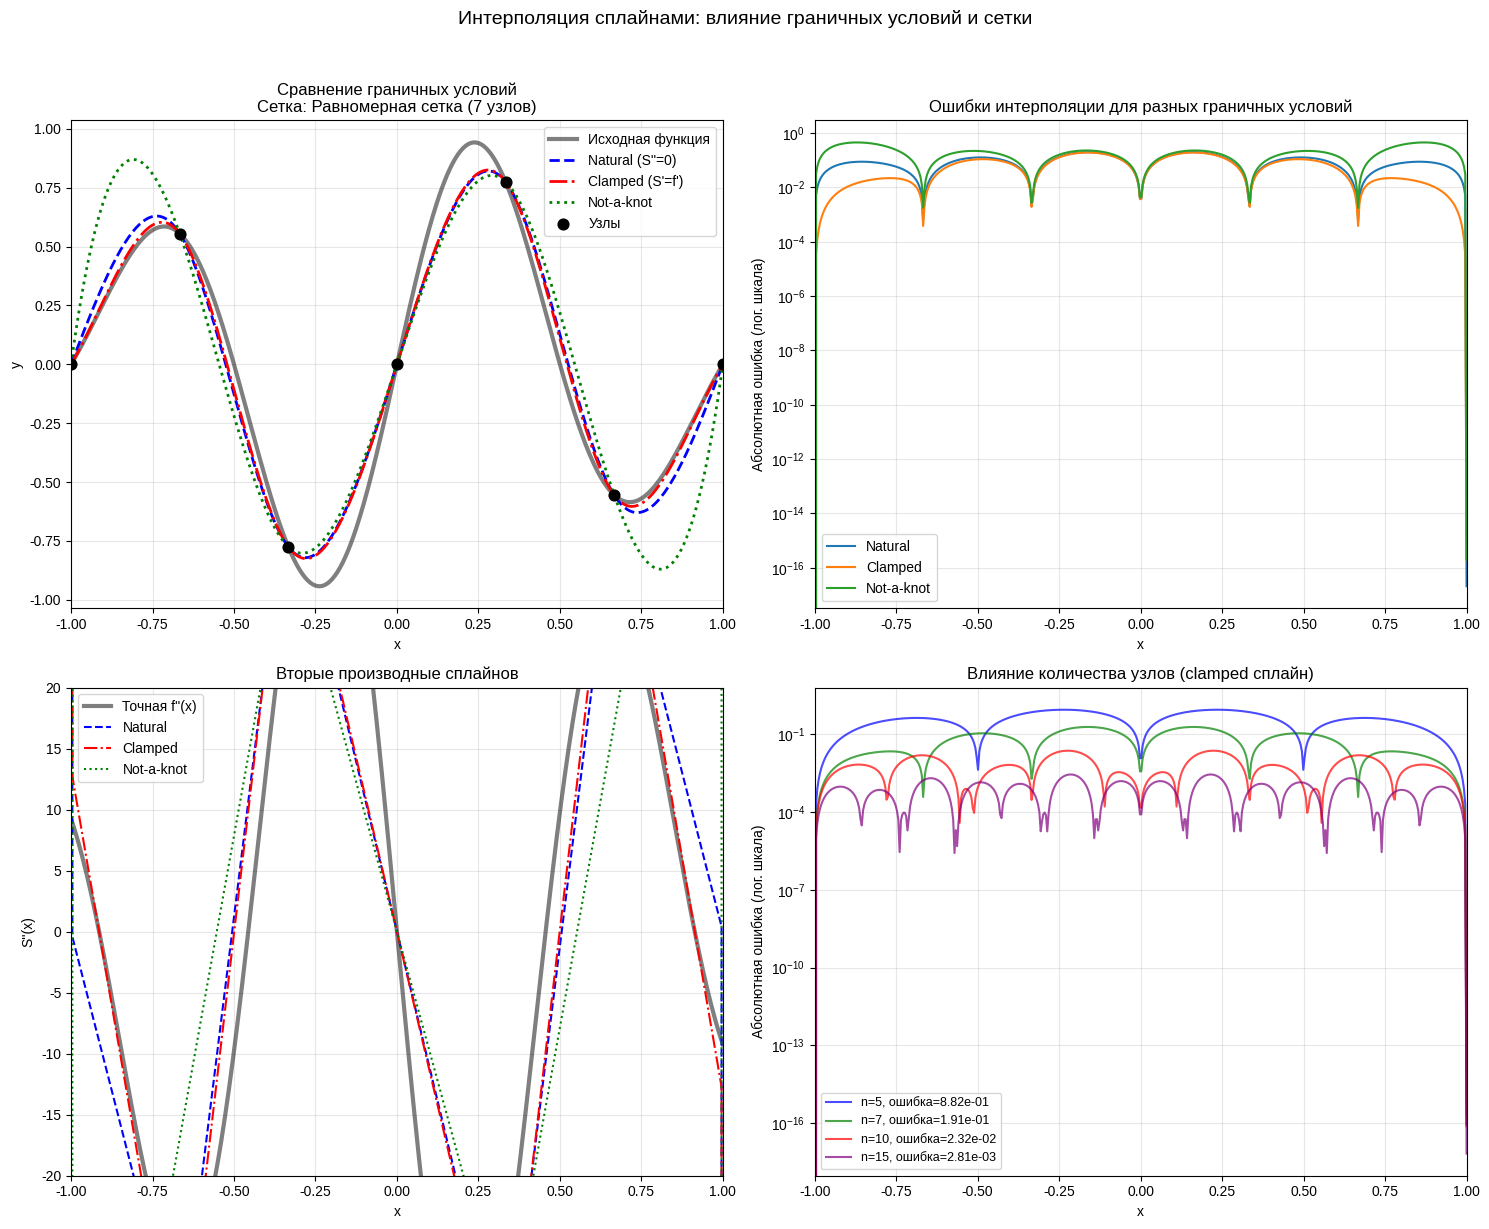


Сетка                          Natural         Clamped         Not-a-knot     
--------------------------------------------------------------------------------
Равномерная сетка (7 узлов)    1.97e-01        1.91e-01        4.51e-01       
Узлы Чебышева (7 узлов)        8.12e-01        8.02e-01        8.26e-01       
Неравномерная сетка (7 узлов)  8.30e-02        6.97e-02        5.26e-01       
Плотная сетка (15 узлов)       1.13e-02        2.81e-03        2.81e-03       


In [15]:
def test_function(x):
    return np.exp(-x**2) * np.sin(2 * np.pi * x)

def derivative_test_function(x):
    return -2*x*np.exp(-x**2)*np.sin(2*np.pi*x) + 2*np.pi*np.exp(-x**2)*np.cos(2*np.pi*x)

# Создаем разные сетки
grids = {
    'Равномерная сетка (7 узлов)': np.linspace(-1, 1, 7),
    'Узлы Чебышева (7 узлов)': np.cos(np.linspace(0, np.pi, 7)),
    'Неравномерная сетка (7 узлов)': np.array([-1, -0.8, -0.5, -0.2, 0.2, 0.6, 1]),
    'Плотная сетка (15 узлов)': np.linspace(-1, 1, 15)
}


# Создаем графики
fig = plt.figure(figsize=(15, 12))

# Берем одну сетку для демонстрации
grid_name = 'Равномерная сетка (7 узлов)'
x_nodes = grids[grid_name]
y_nodes = test_function(x_nodes)
yp_nodes = derivative_test_function(x_nodes)

x_fine = np.linspace(-1, 1, 500)
y_true = test_function(x_fine)

# 1. График: сравнение разных граничных условий
ax1 = plt.subplot(2, 2, 1)
ax1.plot(x_fine, y_true, 'k-', label='Исходная функция', linewidth=3, alpha=0.5)

# Natural сплайн
spline_nat = CubicSpline(x_nodes, y_nodes, bc_type='natural')
y_nat = spline_nat(x_fine)
ax1.plot(x_fine, y_nat, 'b--', label='Natural (S\'\'=0)', linewidth=2)

# Clamped сплайн (используем точные производные)
spline_clamped = CubicSpline(x_nodes, y_nodes, bc_type='clamped',
                           yp_left=yp_nodes[0], yp_right=yp_nodes[-1])
y_clamped = spline_clamped(x_fine)
ax1.plot(x_fine, y_clamped, 'r-.', label='Clamped (S\'=f\')', linewidth=2)

# Not-a-knot сплайн
spline_nak = CubicSpline(x_nodes, y_nodes, bc_type='not-a-knot')
y_nak = spline_nak(x_fine)
ax1.plot(x_fine, y_nak, 'g:', label='Not-a-knot', linewidth=2)

ax1.scatter(x_nodes, y_nodes, color='black', s=60, zorder=5, label='Узлы')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(f'Сравнение граничных условий\nСетка: {grid_name}')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_xlim(-1, 1)

# 2. График: ошибки интерполяции
ax2 = plt.subplot(2, 2, 2)
errors = {
    'Natural': np.abs(y_nat - y_true),
    'Clamped': np.abs(y_clamped - y_true),
    'Not-a-knot': np.abs(y_nak - y_true)
}

for name, error in errors.items():
    ax2.semilogy(x_fine, error, label=name, linewidth=1.5)

ax2.set_xlabel('x')
ax2.set_ylabel('Абсолютная ошибка (лог. шкала)')
ax2.set_title('Ошибки интерполяции для разных граничных условий')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend()
ax2.set_xlim(-1, 1)

# 3. График: вторые производные
ax3 = plt.subplot(2, 2, 3)

# Аналитическая вторая производная тестовой функции
def second_derivative_test(x):
    return (4*x**2 - 2)*np.exp(-x**2)*np.sin(2*np.pi*x) - \
           8*np.pi*x*np.exp(-x**2)*np.cos(2*np.pi*x) - \
           4*np.pi**2*np.exp(-x**2)*np.sin(2*np.pi*x)

y_true_der2 = second_derivative_test(x_fine)

# Вычисляем приближенные вторые производные сплайнов
def approximate_second_derivative(spline, x, h=1e-4):
    """Численная производная сплайна"""
    return (spline(x + h) - 2*spline(x) + spline(x - h)) / h**2

y_nat_der2 = approximate_second_derivative(spline_nat, x_fine)
y_clamped_der2 = approximate_second_derivative(spline_clamped, x_fine)
y_nak_der2 = approximate_second_derivative(spline_nak, x_fine)

ax3.plot(x_fine, y_true_der2, 'k-', label='Точная f\'\'(x)', linewidth=3, alpha=0.5)
ax3.plot(x_fine, y_nat_der2, 'b--', label='Natural', linewidth=1.5)
ax3.plot(x_fine, y_clamped_der2, 'r-.', label='Clamped', linewidth=1.5)
ax3.plot(x_fine, y_nak_der2, 'g:', label='Not-a-knot', linewidth=1.5)

ax3.set_xlabel('x')
ax3.set_ylabel('S\'\'(x)')
ax3.set_title('Вторые производные сплайнов')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.set_xlim(-1, 1)
ax3.set_ylim(-20, 20)

# 4. График: влияние количества узлов
ax4 = plt.subplot(2, 2, 4)
n_nodes_list = [5, 7, 10, 15]
colors = ['blue', 'green', 'red', 'purple']

for n, color in zip(n_nodes_list, colors):
    x_nodes_n = np.linspace(-1, 1, n)
    y_nodes_n = test_function(x_nodes_n)
    yp_nodes_n = derivative_test_function(x_nodes_n)

    # Clamped сплайн (наиболее точный)
    spline = CubicSpline(x_nodes_n, y_nodes_n, bc_type='clamped',
                        yp_left=yp_nodes_n[0], yp_right=yp_nodes_n[-1])
    y_spline = spline(x_fine)
    error = np.max(np.abs(y_spline - y_true))

    ax4.semilogy(x_fine, np.abs(y_spline - y_true),
                color=color, alpha=0.7, linewidth=1.5,
                label=f'n={n}, ошибка={error:.2e}')

ax4.set_xlabel('x')
ax4.set_ylabel('Абсолютная ошибка (лог. шкала)')
ax4.set_title('Влияние количества узлов (clamped сплайн)')
ax4.grid(True, alpha=0.3, which='both')
ax4.legend(fontsize=9)
ax4.set_xlim(-1, 1)

plt.suptitle('Интерполяция сплайнами: влияние граничных условий и сетки',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Заголовок таблицы
print(f"\n{'Сетка':<30} {'Natural':<15} {'Clamped':<15} {'Not-a-knot':<15}")
print("-"*80)

for grid_name, x_nodes in grids.items():
    y_nodes = test_function(x_nodes)
    yp_nodes = derivative_test_function(x_nodes)

    errors = {}

    # Natural
    try:
        spline = CubicSpline(x_nodes, y_nodes, bc_type='natural')
        y_spline = spline(x_fine)
        errors['natural'] = np.max(np.abs(y_spline - y_true))
    except:
        errors['natural'] = np.nan

    # Clamped
    try:
        spline = CubicSpline(x_nodes, y_nodes, bc_type='clamped',
                           yp_left=yp_nodes[0], yp_right=yp_nodes[-1])
        y_spline = spline(x_fine)
        errors['clamped'] = np.max(np.abs(y_spline - y_true))
    except:
        errors['clamped'] = np.nan

    # Not-a-knot
    try:
        spline = CubicSpline(x_nodes, y_nodes, bc_type='not-a-knot')
        y_spline = spline(x_fine)
        errors['not-a-knot'] = np.max(np.abs(y_spline - y_true))
    except:
        errors['not-a-knot'] = np.nan

    print(f"{grid_name:<30} {errors['natural']:<15.2e} {errors['clamped']:<15.2e} {errors['not-a-knot']:<15.2e}")

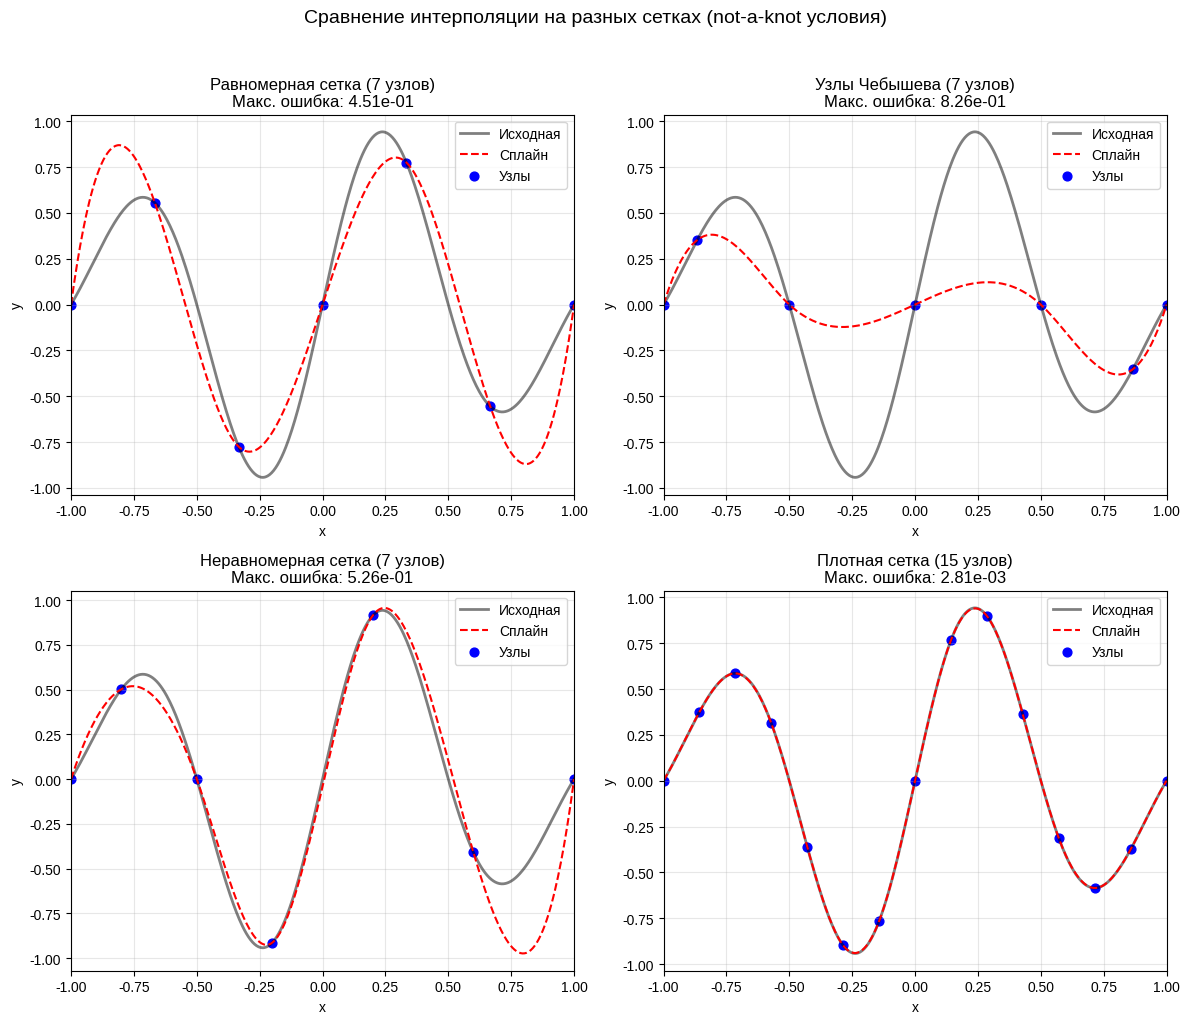

In [16]:
# Дополнительный график: сравнение разных сеток
fig2, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, (grid_name, x_nodes) in enumerate(grids.items()):
    ax = axes[idx//2, idx%2]
    y_nodes = test_function(x_nodes)
    yp_nodes = derivative_test_function(x_nodes)

    # Используем not-a-knot для сравнения сеток
    spline = CubicSpline(x_nodes, y_nodes, bc_type='not-a-knot')
    y_spline = spline(x_fine)
    error = np.max(np.abs(y_spline - y_true))

    ax.plot(x_fine, y_true, 'k-', label='Исходная', linewidth=2, alpha=0.5)
    ax.plot(x_fine, y_spline, 'r--', label='Сплайн', linewidth=1.5)
    ax.scatter(x_nodes, y_nodes, color='blue', s=40, label='Узлы')

    ax.set_title(f'{grid_name}\nМакс. ошибка: {error:.2e}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlim(-1, 1)

plt.suptitle('Сравнение интерполяции на разных сетках (not-a-knot условия)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

##### Выводы по оценкам

1. ВЛИЯНИЕ ГРАНИЧНЫХ УСЛОВИЙ:
   - Natural ($S''=0$): самые гладкие сплайны на концах, но могут иметь
     большую ошибку, если реальная вторая производная не нулевая
   - Clamped ($S'=f'$): наиболее точные при известных производных,
     но требуют дополнительной информации
   - Not-a-knot: хороший компромисс, часто используется по умолчанию
     (третья производная непрерывна на концах)

2. ВЛИЯНИЕ СЕТКИ:
   - Равномерная сетка: простая, но не всегда оптимальная
   - Узлы Чебышева: минимизируют ошибку интерполяции
   - Плотность сетки: больше узлов → меньше ошибка, но сложнее вычисления

3. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:
   - Если известны производные на границах → используйте clamped
   - Если нет информации о производных → используйте not-a-knot
   - Для гладких функций → узлы Чебышева дают лучшую точность
   - Natural условия хороши для задач с нулевой кривизной на границах

# Численное дифференцирование

### (1) Реализация приближённого дифференциирования первой, второй, третьей производной по 4 точкам

In [17]:
def D3(f, x0, h):
    return (-1 * f(x0) + 3*f(x0+h) - 3*f(x0+2*h) + f(x0+3*h)) / h**3  # O(h)

def D2(f, x0, h):
    return (2*f(x0) - 5*f(x0+h) + 4*f(x0+2*h) - f(x0+3*h)) / h**2  # O(h^2)

def D1(f, x0, h):
    return (-11/6*f(x0) + 3*f(x0+h) - 3/2*f(x0+2*h) + 1/3*f(x0+3*h)) / h  # O(h^3)

### Построение графиков и аппроксимация в матричном виде


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ПОЛИНОМ СТЕПЕНИ 1: f(x) = x^1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

f(x) = x                                                 
1st derivative: 1                                               
Коэффициенты (лог-пространство): a0=-15.566, a1=-1.190, a2=-0.048, a3=-0.003

f(x) = x                                                 
2nd derivative: 0                                               
Коэффициенты (лог-пространство): a0=-15.686, a1=-2.082, a2=-0.004, a3=-0.000

f(x) = x                                                 
3rd derivative: 0                                               
Коэффициенты (лог-пространство): a0=-15.155, a1=-2.826, a2=0.034, a3=0.002



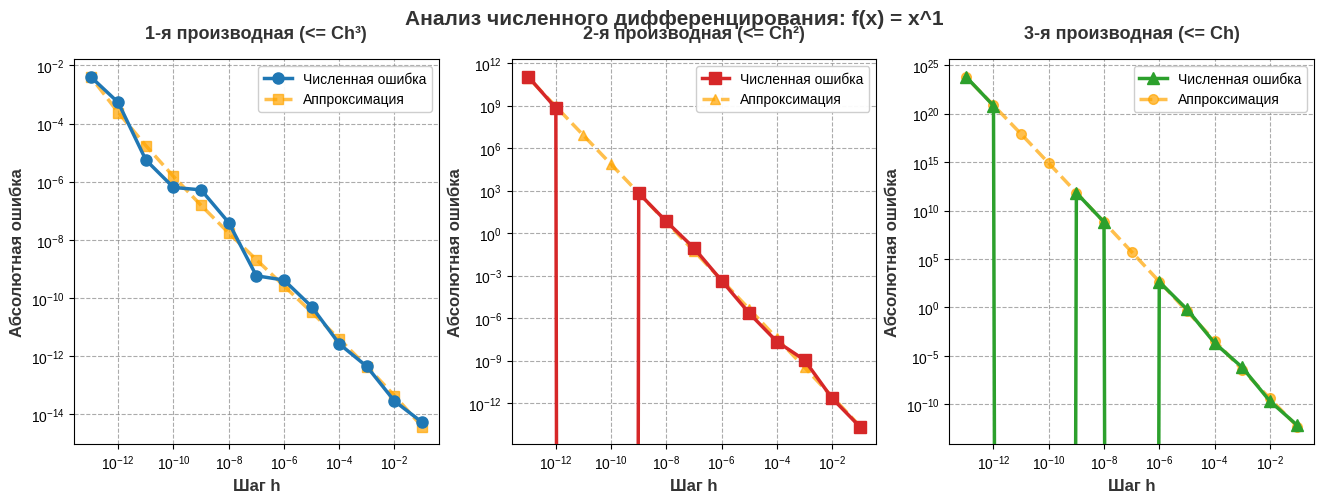



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ПОЛИНОМ СТЕПЕНИ 2: f(x) = x^2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

f(x) = x**2                                              
1st derivative: 2*x                                             
Коэффициенты (лог-пространство): a0=-15.681, a1=-1.259, a2=-0.049, a3=-0.002

f(x) = x**2                                              
2nd derivative: 2                                               
Коэффициенты (лог-пространство): a0=-17.759, a1=-4.123, a2=-0.406, a3=-0.020

f(x) = x**2                                              
3rd derivative: 0                                               
Коэффициенты (лог-пространство): a0=-15.244, a1=-2.923, a2=0.022, a3=0.001



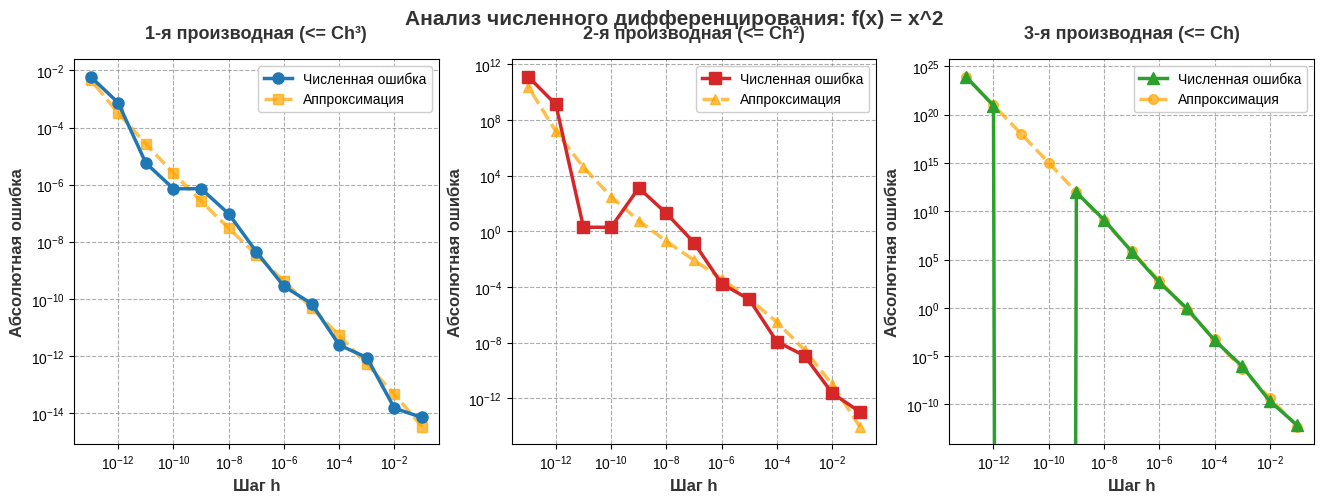



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ПОЛИНОМ СТЕПЕНИ 3: f(x) = x^3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

f(x) = x**3                                              
1st derivative: 3*x**2                                          
Коэффициенты (лог-пространство): a0=-15.313, a1=-1.171, a2=-0.039, a3=-0.002

f(x) = x**3                                              
2nd derivative: 6*x                                             
Коэффициенты (лог-пространство): a0=-17.053, a1=-3.740, a2=-0.339, a3=-0.016

f(x) = x**3                                              
3rd derivative: 6                                               
Коэффициенты (лог-пространство): a0=-23.209, a1=-9.641, a2=-1.262, a3=-0.061



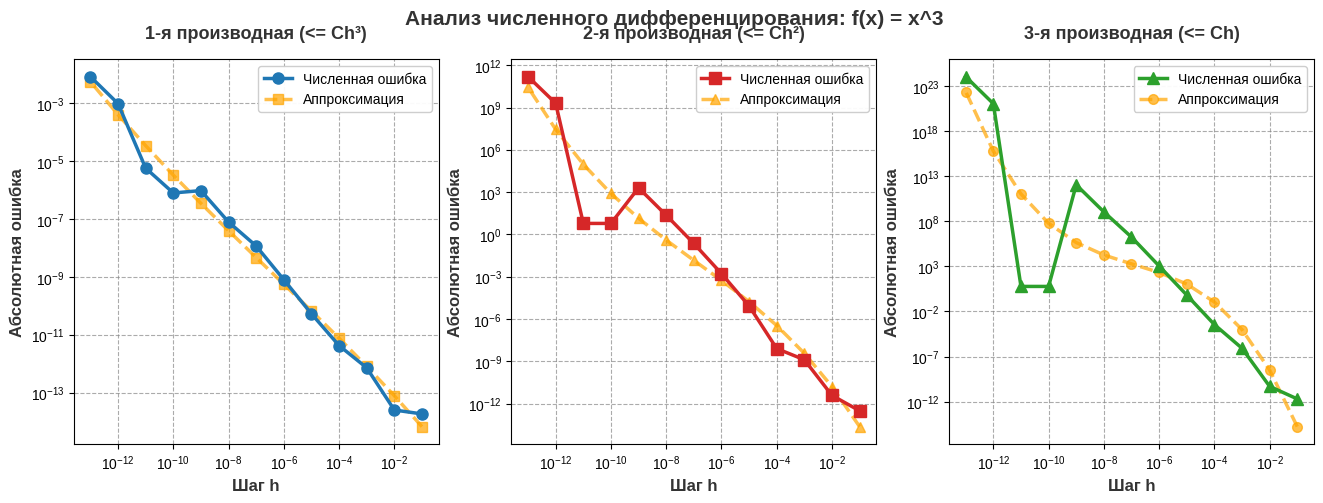



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ПОЛИНОМ СТЕПЕНИ 4: f(x) = x^4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

f(x) = x**4                                              
1st derivative: 4*x**3                                          
Коэффициенты (лог-пространство): a0=2.516, a1=5.607, a2=0.763, a3=0.028

f(x) = x**4                                              
2nd derivative: 12*x**2                                         
Коэффициенты (лог-пространство): a0=0.959, a1=2.772, a2=0.406, a3=0.011

f(x) = x**4                                              
3rd derivative: 24*x                                            
Коэффициенты (лог-пространство): a0=-3.886, a1=-2.554, a2=-0.439, a3=-0.031



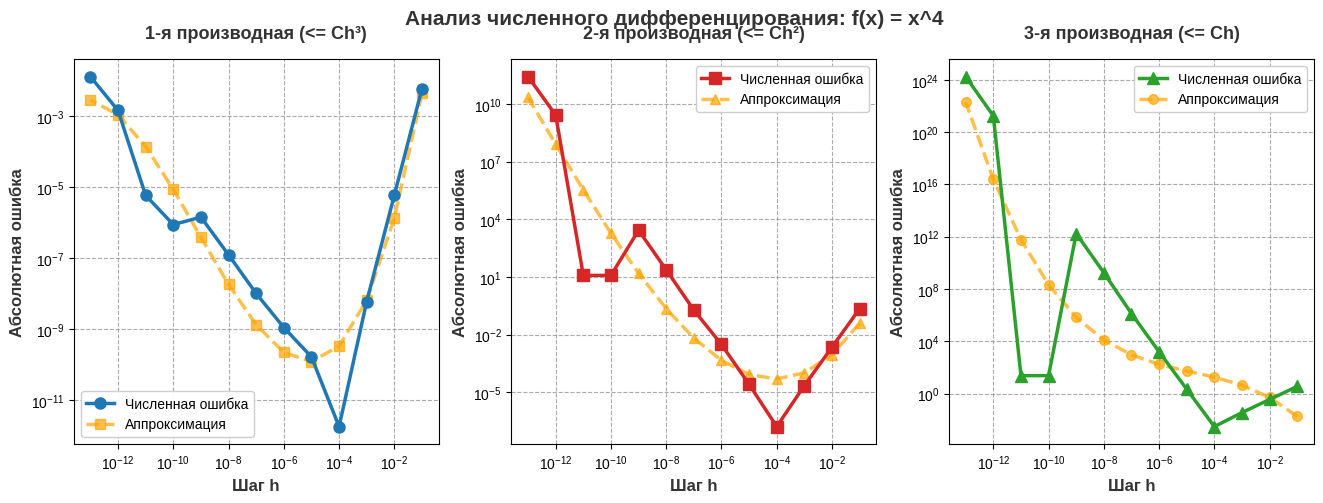

In [18]:
def create_graphs(f_expr, poly_degree, write_df=True):
    x = sp.Symbol('x')

    # Вычисляем производные
    der_f1 = sp.diff(f_expr, x, 1)
    der_f2 = sp.diff(f_expr, x, 2)
    der_f3 = sp.diff(f_expr, x, 3)

    # Преобразуем в числовые функции
    der_f1_exact = sp.lambdify(x, der_f1, 'numpy')
    der_f2_exact = sp.lambdify(x, der_f2, 'numpy')
    der_f3_exact = sp.lambdify(x, der_f3, 'numpy')
    f_num = sp.lambdify(x, f_expr, 'numpy')

    def calculate_error(f_approx, f_exact, der_num=""):
        """Вычисляет ошибки и создаёт таблицу"""
        errs = []
        data = []

        print(f'f(x) = {str(f_expr):<50}')
        print(f'{der_num} derivative: {str([der_f1, der_f2, der_f3][int(der_num[0])-1]):<48}')

        for h in hs:
            approx = f_approx(f_num, x0, h)
            exact = f_exact(x0)
            abs_error = abs(approx - exact)
            errs.append(abs_error)
            data.append({
                'h': f'{h:.0e}',
                'Приблиз.': f'{approx:.6e}',
                'Точное': f'{exact:.6e}',
                'Ошибка': f'{abs_error:.6e}'
            })

        if write_df:
            df = pd.DataFrame(data)
            print(df.to_string(index=False))
        return np.array(errs)

    def calculate_approx(h_vals, errors):
        """
        Аппроксимация ошибки полиномом в логарифмическом пространстве
        log(error) ≈ a0 + a1*log(h) + a2*log(h)^2 + a3*log(h)^3
        """
        # Фильтруем только валидные значения (ошибка > 0)
        valid_mask = errors > 1e-20
        h_valid = h_vals[valid_mask]
        err_valid = errors[valid_mask]

        if len(h_valid) < 4:
            print('Недостаточно данных для аппроксимации')
            return np.full_like(errors, np.nan)

        # Работаем в логарифмическом пространстве
        log_h = np.log10(h_valid)
        log_err = np.log10(err_valid)

        # Строим матрицу для МНК: log(error) ≈ a0 + a1*log(h) + a2*log(h)^2 + a3*log(h)^3
        X = np.column_stack([np.ones_like(log_h), log_h, log_h**2, log_h**3])

        # Решаем систему для коэффициентов
        alpha = np.linalg.solve(X.T @ X, X.T @ log_err)
        a0, a1, a2, a3 = alpha

        # Вычисляем аппроксимацию для всех точек
        log_h_all = np.log10(h_vals)
        log_approx = a0 + a1*log_h_all + a2*log_h_all**2 + a3*log_h_all**3
        approx_errors = 10**log_approx

        print(f'Коэффициенты (лог-пространство): a0={a0:.3f}, a1={a1:.3f}, a2={a2:.3f}, a3={a3:.3f}', end='\n\n')

        return approx_errors


    x0 = 1.0
    hs = np.logspace(start=-1, stop=-13, num=13, base=10)


    fig = plt.figure(figsize=(16, 5))

    # Цвета для каждого графика
    colors = ['#1f77b4', '#d62728', '#2ca02c']

    # 1-я производная
    ax1 = plt.subplot(1, 3, 1)
    errs1 = calculate_error(D1, der_f1_exact, "1st")
    ax1.loglog(hs, errs1, 'o-', linewidth=2.5, markersize=8, color=colors[0], label='Численная ошибка', zorder=3)

    approx_errs1 = calculate_approx(hs, errs1)
    ax1.loglog(hs, approx_errs1, 's--', linewidth=2.5, markersize=7, color='orange', alpha=0.7, label='Аппроксимация')

    ax1.set_xlabel('Шаг h', fontsize=12, fontweight='bold', color='#333333')
    ax1.set_ylabel('Абсолютная ошибка', fontsize=12, fontweight='bold', color='#333333')
    ax1.set_title('1-я производная (<= Сh³)', fontsize=13, fontweight='bold', color='#333333', pad=15)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7, color='#888888')
    ax1.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='#cccccc')

    # 2-я производная
    ax2 = plt.subplot(1, 3, 2)
    errs2 = calculate_error(D2, der_f2_exact, "2nd")
    ax2.loglog(hs, errs2, 's-', linewidth=2.5, markersize=8, color=colors[1], label='Численная ошибка', zorder=3)

    approx_errs2 = calculate_approx(hs, errs2)
    ax2.loglog(hs, approx_errs2, '^--', linewidth=2.5, markersize=7, color='orange', alpha=0.7, label='Аппроксимация')

    ax2.set_xlabel('Шаг h', fontsize=12, fontweight='bold', color='#333333')
    ax2.set_ylabel('Абсолютная ошибка', fontsize=12, fontweight='bold', color='#333333')
    ax2.set_title('2-я производная (<= Ch²)', fontsize=13, fontweight='bold', color='#333333', pad=15)
    ax2.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7, color='#888888')
    ax2.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='#cccccc')

    # 3-я производная
    ax3 = plt.subplot(1, 3, 3)
    errs3 = calculate_error(D3, der_f3_exact, "3rd")
    ax3.loglog(hs, errs3, '^-', linewidth=2.5, markersize=8, color=colors[2], label='Численная ошибка', zorder=3)

    approx_errs3 = calculate_approx(hs, errs3)
    ax3.loglog(hs, approx_errs3, 'o--', linewidth=2.5, markersize=7, color='orange', alpha=0.7, label='Аппроксимация')

    ax3.set_xlabel('Шаг h', fontsize=12, fontweight='bold', color='#333333')
    ax3.set_ylabel('Абсолютная ошибка', fontsize=12, fontweight='bold', color='#333333')
    ax3.set_title('3-я производная (<= Ch)', fontsize=13, fontweight='bold', color='#333333', pad=15)
    ax3.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7, color='#888888')
    ax3.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='#cccccc')

    # Общий заголовок
    fig.suptitle(f'Анализ численного дифференцирования: f(x) = x^{poly_degree}',
                 fontsize=15, fontweight='bold', color='#333333', y=0.98)

    plt.show()


# Основной код
x = sp.Symbol('x')

# Тестируем на разных степенях полинома
for degree in range(1, 5):
    f = x**degree
    print(f'\n{"━"*70}')
    print(f'  ПОЛИНОМ СТЕПЕНИ {degree}: f(x) = x^{degree}')
    print(f'{"━"*70}\n')
    create_graphs(f, degree, write_df=False)
    print()

### (2) **Вторая производная** по пяти точкам с использованием многочлена Ньютона:

Пусть заданы пять точек $(x_i, y_i)$, $y_i = f(x_i)$, $i = 0,\dots,4$.

Интерполяционный многочлен Ньютона степени 4:
$$
L_4(x) = f[x_0]
+ f[x_0,x_1](x-x_0)
+ f[x_0,x_1,x_2](x-x_0)(x-x_1)
+ f[x_0,x_1,x_2,x_3](x-x_0)(x-x_1)(x-x_2)
+ f[x_0,x_1,x_2,x_3,x_4](x-x_0)(x-x_1)(x-x_2)(x-x_3).
$$

Разделённые разности:
$$
f[x_i] = y_i,
$$
$$
f[x_i,x_{i+1}] = \frac{f[x_{i+1}] - f[x_i]}{x_{i+1}-x_i},
$$
$$
f[x_i,\dots,x_{i+k}] =
\frac{f[x_{i+1},\dots,x_{i+k}] - f[x_i,\dots,x_{i+k-1}]}{x_{i+k}-x_i}.
$$

Ошибка (остаточный член):
$$
R_4(x) = f(x) - L_4(x)
= f[x, x_0,x_1,x_2,x_3,x_4] (x-x_0)(x-x_1)(x-x_2)(x-x_3)(x-x_4),
$$

#### **Первая производная**:

\begin{align}
\textbf{L'(x)} = f[x_0, x_1] + f[x_0, x_1, x_2]((x - x_1) + (x - x_2)) + f[x_0, x_1, x_2, x_3]((x - x_1)(x - x_2) + (x - x_0)(2x - x_1 - x_2)) + \\ f[x_0, x_1, x_2, x_3, x_4]((x-x_1)(x-x_2)(x-x_3) + (x-x_0)(x-x_2)(x-x_3) + (x - x_0)(x - x_1)(2x - x_1 - x_2))
\end{align}

\begin{align}
\textbf{R'(x)} = f[x, x, x_0, x_1, x_2, x_3, x_4](x - x_0))(x - x_1)(x - x_2)(x - x_3)(x - x_4) + f[x, x_0, x_1, x_2, x_3, x_4]((x - x_1)(x - x_2)(x - x_3)(x - x_4) + &\\(x-x_0)(x-x_2)(x-x_3)(x-x_4) + (x-x_0)(x-x_1)(x-x_3)(x-x_4) + (x-x_0)(x-x_1)(x-x_2)(2x - x_3 - x_4))
\end{align}

#### **Вторая производная**

\begin{align}
L''(x) = 2f[x_0, x_1, x_2] + 2f[x_0, x_1, x_2, x_3](3x - x_0 - x_1 - x_2)) + 2f[x_0, x_1, x_2, x_3, x_4]((x-x_2)(x-x_3) + (x - x_1)(2x - x_2 - x_3) + 2(x-x_0)(3x - x_1 - x_2 - x_3))
\end{align}

\begin{align}
R''(x) &= f[x, x, x, x_0, x_1, x_2, x_3, x_4](x - x_0))(x - x_1)(x - x_2)(x - x_3)(x - x_4) + \\f[x, x, x_0, x_1, x_2, x_3, x_4]((x - x_1))(x - x_2)(x - x_3)(x - x_4) + (x-x_0)(x-x_1)(x-x_3)(x-x_4) + (x-x_0)(x-x_1)(x-x_2)(2x - x_3 - x_4)) + \\f[x, x, x_0, x_1, x_2, x_3, x_4](x - x_0))(x - x_1)(x - x_2)(x - x_3)(x - x_4) + \\f[x, x_0, x_1, x_2, x_3, x_4]((x - x_1)(x - x_2)(x - x_3)(x - x_4) + \\(x-x_0)(x-x_2)(x-x_3)(x-x_4) + (x-x_0)(x-x_1)(x-x_3)(x-x_4) + (x-x_0)(x-x_1)(x-x_2)(2x - x_3 - x_4)) + \\f[x, x_0, x_1, x_2, x_3, x_4]((x - x_2)(x - x_3)(x - x_4) + (x - x_1)(x - x_3)(x - x_4) + (x - x_1)(x - x_2)(2x - x_3 - x_4) + (x - x_2)(x - x_3)(x - x_4) + \\(x - x_0)(x - x_3)(x - x_4) + (x - x_0)(x - x_2)(2x - x_3 - x_4) + (x - x_1)(x - x_3)(x - x_4) + (x - x_0)(x - x_3)(x-x_4) + \\(x - x0)(x - x_1)(2x - x_3 - x_4) + (x - x_1)(x - x_2)(2x - x_3 - x_4) + (x - x_0)(x - x_2)(2x - x_3 - x_4) + \\(x - x_0)(x - x1)(4x - 2x_2 - x_3 - x_4))
\end{align}

Тест на функции:

=== Результаты анализа ошибки ===
            h  Actual Error (|E|)  Theoretical Bound  Ratio (|E|/Bound)
0  1.0000e-01          6.3941e-05         1.0261e-04         6.2316e-01
1  7.8476e-02          3.2565e-05         4.9589e-05         6.5670e-01
2  6.1585e-02          1.6411e-05         2.3966e-05         6.8477e-01
3  4.8329e-02          8.1999e-06         1.1583e-05         7.0795e-01
4  3.7927e-02          4.0690e-06         5.5978e-06         7.2689e-01
5  2.9764e-02          2.0081e-06         2.7054e-06         7.4225e-01
6  2.3357e-02          9.8664e-07         1.3075e-06         7.5461e-01
7  1.8330e-02          4.8310e-07         6.3190e-07         7.6452e-01
8  1.4384e-02          2.3589e-07         3.0539e-07         7.7242e-01
9  1.1288e-02          1.1495e-07         1.4759e-07         7.7881e-01
10 8.8587e-03          5.5885e-08         7.1331e-08         7.8346e-01
11 6.9519e-03          2.7148e-08         3.4474e-08         7.8748e-01
12 5.4556e-03          1.3254e

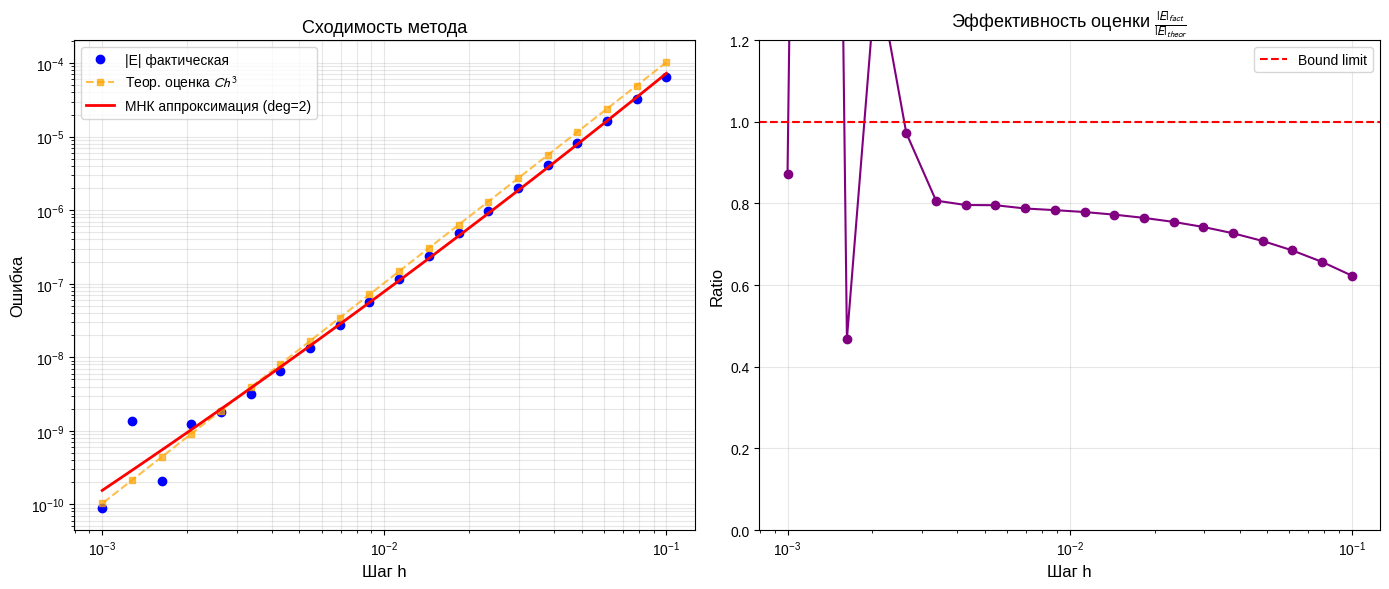

In [19]:
# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4e}'.format)

def D2_5points_forward(f, x0, h):
    """Вторая производная по формуле 5 точек вперёд"""
    return (35/12*f(x0) - 26/3*f(x0+h) + 19/2*f(x0+2*h)
            - 14/3*f(x0+3*h) + 11/12*f(x0+4*h)) / h**2

# Символьные вычисления
x_sym = sp.Symbol('x')
f_sym = sp.log(x_sym + 1)
d2f_sym = sp.diff(f_sym, x_sym, 2)
d5f_sym = sp.diff(f_sym, x_sym, 5)
d6f_sym = sp.diff(f_sym, x_sym, 6)

# Создаем функции для numpy
f_analitycs = sp.lambdify(x_sym, f_sym, 'numpy')
d2f_analitycs = sp.lambdify(x_sym, d2f_sym, 'numpy')
d5f_analitycs = sp.lambdify(x_sym, d5f_sym, 'numpy')
d6f_analitycs = sp.lambdify(x_sym, d6f_sym, 'numpy')

# Параметры
x0 = 2.0
a, b = 1, 10
h_values = np.logspace(start=-1, stop=-3, num=20, base=10)

# Список для сбора данных
data_list = []
h_max = np.max(h_values)

for h in h_values:
    if x0 + 4*h > b:
        continue

    d2f_approx = D2_5points_forward(f_analitycs, x0, h)
    d2f_true = d2f_analitycs(x0)
    error = np.abs(d2f_approx - d2f_true)

    # Оценка константы
    x_test = np.linspace(x0, x0 + 4*h, 100)
    f5_abs_max = np.max(np.abs(d5f_analitycs(x_test)))
    f6_abs_max = np.max(np.abs(d6f_analitycs(x_test)))
    M = max(f5_abs_max, f6_abs_max)
    C = M * (h_max/15 + 37/60)
    bound = C * h**3

    ratio = error / bound if bound != 0 else 0

    data_list.append({
        'h': h,
        'Actual Error (|E|)': error,
        'Theoretical Bound': bound,
        'Ratio (|E|/Bound)': ratio
    })

df = pd.DataFrame(data_list)
h_vals = df['h'].values
errors = df['Actual Error (|E|)'].values
bounds = df['Theoretical Bound'].values
ratios = df['Ratio (|E|/Bound)'].values

print("=== Результаты анализа ошибки ===")
print(df)
print("\n")


log_h = np.log10(h_vals)
log_err = np.log10(errors)

# 2 - увидеть кривизну, а вообще в идеале 1
poly_degree = 2

# Формируем матрицу Вандермонда вручную: [1, x, x^2, x^3...]
# column_stack соединяет массивы как столбцы, вот такие пироги!
X_columns = [np.ones_like(log_h)]
for i in range(1, poly_degree + 1):
    X_columns.append(log_h**i)

X = np.column_stack(X_columns)

# Решаем нормальное уравнение: (X^T * X) * A = X^T * Y
alpha = np.linalg.solve(X.T @ X, X.T @ log_err)

print(f"Коэффициенты полинома аппроксимации (степень {poly_degree}):")
for i, coef in enumerate(alpha):
    print(f"a{i} (при log(h)^{i}): {coef:.4f}")

print(f"\nОсновной наклон (a1): {alpha[1]:.4f} (это и есть ваш экспериментальный порядок p)")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 1
ax1.loglog(h_vals, errors, 'o', label='|E| фактическая', markersize=6, color='blue')
ax1.loglog(h_vals, bounds, 's--', label='Теор. оценка $Ch^3$', markersize=4, color='orange', alpha=0.7)

# Рисуем аппроксимацию МНК
# Создаем плотную сетку для гладкой линии
log_h_dense = np.linspace(min(log_h), max(log_h), 100)
log_err_fit = np.zeros_like(log_h_dense)
for i, coef in enumerate(alpha):
    log_err_fit += coef * (log_h_dense**i)
err_fit = 10**log_err_fit  # перейти из лог. пространства
h_dense = 10**log_h_dense  # перейти из лог. пространства

ax1.loglog(h_dense, err_fit, 'r-', label=f'МНК аппроксимация (deg={poly_degree})', linewidth=2)

ax1.set_xlabel('Шаг h', fontsize=12)
ax1.set_ylabel('Ошибка', fontsize=12)
ax1.set_title(f'Сходимость метода', fontsize=13)
ax1.legend()
ax1.grid(True, which='both', alpha=0.3)

# График 2
ax2.semilogx(h_vals, ratios, 'o-', color='purple', markersize=6)
ax2.axhline(1, color='red', linestyle='--', label='Bound limit')
ax2.set_xlabel('Шаг h', fontsize=12)
ax2.set_ylabel('Ratio', fontsize=12)
ax2.set_title(r'Эффективность оценки $\frac{|E|_{fact}}{|E|_{theor}}$', fontsize=13)
ax2.set_ylim(0, 1.2)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Численное интегрирование

### (1) Реализация методов Ньютона-Котеса

In [20]:
def integrate_left_rectangles(f: ScalarFunc, a: float, b: float, n=1) -> float:
  """ Метод левых прямоугольников """
  h = (b - a) / n
  return h * sum(f(a + h * i) for i in range(0, n))

def integrate_right_rectangles(f: ScalarFunc, a: float, b: float, n=1) -> float:
  """ Метод правых прямоугольников """
  h = (b - a) / n
  return h * sum(f(a + h * i) for i in range(1, n + 1))

def integrate_mid_rectangles(f: ScalarFunc, a: float, b: float, n=1) -> float:
  """ Метод средних прямоугольников """
  h = (b - a) / n
  return h * sum(f(a + h * i + h / 2) for i in range(0, n))

def integrate_trapezoidal(f: ScalarFunc, a: float, b: float, n=1) -> float:
  """ Метод трапеций """
  h = (b - a) / n
  return h * ((f(a) + f(b))/2 + sum(f(a + h * i) for i in range(1, n)))

def integrate_simpson(f: ScalarFunc, a: float, b: float, k=1) -> float:
  """ Метод Симпсона """
  n = 2 * k
  h = (b - a) / n
  s = f(a) + f(b)
  s += 2 * sum(f(a + i * h) for i in range(2, n, 2))
  s += 4 * sum(f(a + i * h) for i in range(1, n, 2))
  return h / 3 * s

def integrate_method_38(f: ScalarFunc, a: float, b: float, k=1) -> float:
  """ Метод 3/8 """
  n = 3 * k
  h = (b - a) / n
  s = f(a) + f(b)
  s += 3 * sum(f(a + h*i) for i in range(1, n) if i % 3 != 0)
  s += 2 * sum(f(a + h*i) for i in range(3, n, 3))
  return 0.375 * h * s

In [21]:
# Теоретическая верхняя граница ошибок методов
err_left_rectangles  = lambda a, b, h, M: (b - a) / 2   * h    * M[1]
err_right_rectangles = lambda a, b, h, M: (b - a) / 2   * h    * M[1]
err_mid_rectangles   = lambda a, b, h, M: (b - a) / 24  * h**2 * M[2]
err_trapezoidal      = lambda a, b, h, M: (b - a) / 12  * h**2 * M[2]
err_simpson          = lambda a, b, h, M: (b - a) / 180 * h**4 * M[4]
err_method_38        = lambda a, b, h, M: (b - a) / 80  * h**4 * M[4]

In [22]:
Method = namedtuple('Method' , 'title integrate dh error color')
methods = [
  Method("Метод левых",    integrate_left_rectangles,  1, err_left_rectangles,  "tab:blue"),
  Method("Метод правых",   integrate_right_rectangles, 1, err_right_rectangles, "tab:orange"),
  Method("Метод средних",  integrate_mid_rectangles,   1, err_mid_rectangles,   "tab:green"),
  Method("Метод трапеций", integrate_trapezoidal,      1, err_trapezoidal,      "tab:red"),
  Method("Метод Симпсона", integrate_simpson,          2, err_simpson,          "tab:purple"),
  Method("Метод 3/8",      integrate_method_38,        3, err_method_38,        "tab:brown")
]

### Простой тест работоспособности

In [23]:
def test_simple(f: ScalarFunc, F: ScalarFunc, a: float, b: float, n=1):
  """ Проверка всех методов на конкретной ситуации """
  correct = F(b) - F(a)
  print(f"Истинное значение {correct}")
  print(f"Шаг {(b - a) / n:.3f}")
  for m in methods:
    val = m.integrate(f, a, b, (n+m.dh-1)//m.dh)
    print(f"{m.title}:\t{val:.10f}\t({abs((correct-val)/correct*100):.8f}%)")

### (2) Тест зависимости err(h)

In [24]:
def test_h(title: str, f: ScalarFunc, F: ScalarFunc, a: float, b: float, M, n_axis):
  """ Зависимость ошибки от шага h
    f - функция, [a, b] - границы интегрирования
    F - неопределённый интеграл с const=0
    M - список sup производных i-ого порядка
    n_axis - итерируемый объект с необходимыми n
  """
  plt.figure(figsize=(9, 6))
  truly = F(b) - F(a)  # Истинное значение
  h_axis = [(b - a) / n for n in n_axis]

  for m in methods:
    # Фактическая ошибка
    err_axis = []
    for n in n_axis:
      Fx = m.integrate(f, a, b, (n + m.dh - 1) // m.dh)
      err = abs(truly - Fx)
      err_axis.append(err)
    plt.plot(h_axis, err_axis, label=m.title, color=m.color)
    # Теоретическая ошибка
    theory = [m.error(a, b, h, M) for h in h_axis]
    plt.plot(h_axis, theory, '--', alpha=0.7, label=f"теор. sup ошибки", color=m.color)

  plt.axhline(sys.float_info.epsilon, color='black', label="machine ε")

  plt.xscale('log')
  plt.yscale('log')
  plt.xlabel("h (log)")
  plt.ylabel("Ошибка (log)")
  plt.title(f"Err(h) для {title} на [{a}, {b}]")
  plt.legend()
  plt.grid(True, which="both", ls="--")
  plt.show()

### $f(x) = x^n$

###### Тестовые запуски для разных степеней

In [25]:
a, b, n = 1, 3, 100

In [26]:
print("f(x) = 1")
test_simple(f = lambda x: 1, F = lambda x: x, a=a, b=b, n=n)
print("f(x) = x")
test_simple(f = lambda x: x, F = lambda x: x**2/2, a=a, b=b, n=n)
print("f(x) = x²")
test_simple(f = lambda x: x**2, F = lambda x: x**3/3, a=a, b=b, n=n)
print("f(x) = x³")
test_simple(f = lambda x: x**3, F = lambda x: x**4/4, a=a, b=b, n=n)
print("f(x) = x⁴")
test_simple(f = lambda x: x**4, F = lambda x: x**5/5, a=a, b=b, n=n)
print("f(x) = x⁵")
test_simple(f = lambda x: x**5, F = lambda x: x**6/6, a=a, b=b, n=n)

f(x) = 1
Истинное значение 2
Шаг 0.020
Метод левых:	2.0000000000	(0.00000000%)
Метод правых:	2.0000000000	(0.00000000%)
Метод средних:	2.0000000000	(0.00000000%)
Метод трапеций:	2.0000000000	(0.00000000%)
Метод Симпсона:	2.0000000000	(0.00000000%)
Метод 3/8:	2.0000000000	(0.00000000%)
f(x) = x
Истинное значение 4.0
Шаг 0.020
Метод левых:	3.9800000000	(0.50000000%)
Метод правых:	4.0200000000	(0.50000000%)
Метод средних:	4.0000000000	(0.00000000%)
Метод трапеций:	4.0000000000	(0.00000000%)
Метод Симпсона:	4.0000000000	(0.00000000%)
Метод 3/8:	4.0000000000	(0.00000000%)
f(x) = x²
Истинное значение 8.666666666666666
Шаг 0.020
Метод левых:	8.5868000000	(0.92153846%)
Метод правых:	8.7468000000	(0.92461538%)
Метод средних:	8.6666000000	(0.00076923%)
Метод трапеций:	8.6668000000	(0.00153846%)
Метод Симпсона:	8.6666666667	(0.00000000%)
Метод 3/8:	8.6666666667	(0.00000000%)
f(x) = x³
Истинное значение 20.0
Шаг 0.020
Метод левых:	19.7408000000	(1.29600000%)
Метод правых:	20.2608000000	(1.30400000

In [27]:
print("f(x) = 1/x")
test_simple(f = lambda x: 1/x, F = lambda x: math.log(x), a=a, b=b, n=n)
print("f(x) = 1/x²")
test_simple(f = lambda x: x**(-2), F = lambda x: x**(-1) / (-1), a=a, b=b, n=n)
print("f(x) = 1/x³")
test_simple(f = lambda x: x**(-3), F = lambda x: x**(-2) / (-2), a=a, b=b, n=n)
print("f(x) = 1/x⁴")
test_simple(f = lambda x: x**(-4), F = lambda x: x**(-3) / (-3), a=a, b=b, n=n)
print("f(x) = 1/x⁵")
test_simple(f = lambda x: x**(-5), F = lambda x: x**(-4) / (-4), a=a, b=b, n=n)

f(x) = 1/x
Истинное значение 1.0986122886681098
Шаг 0.020
Метод левых:	1.1053085836	(0.60952304%)
Метод правых:	1.0919752503	(0.60412927%)
Метод средних:	1.0985974750	(0.00134840%)
Метод трапеций:	1.0986419170	(0.00269689%)
Метод Симпсона:	1.0986122939	(0.00000048%)
Метод 3/8:	1.0986122996	(0.00000099%)
f(x) = 1/x²
Истинное значение 0.6666666666666667
Шаг 0.020
Метод левых:	0.6756197478	(1.34296217%)
Метод правых:	0.6578419700	(1.32370450%)
Метод средних:	0.6666345725	(0.00481412%)
Метод трапеций:	0.6667308589	(0.00962883%)
Метод Симпсона:	0.6666666879	(0.00000318%)
Метод 3/8:	0.6666667107	(0.00000661%)
f(x) = 1/x³
Истинное значение 0.4444444444444444
Шаг 0.020
Метод левых:	0.4541728262	(2.18888589%)
Метод правых:	0.4349135669	(2.14444744%)
Метод средних:	0.4443950734	(0.01110849%)
Метод трапеций:	0.4445431966	(0.02221923%)
Метод Симпсона:	0.4444444976	(0.00001196%)
Метод 3/8:	0.4444445547	(0.00002481%)
f(x) = 1/x⁴
Истинное значение 0.32098765432098764
Шаг 0.020
Метод левых:	0.33099695

##### $f(x) = x$

Есть ошибка только у левых и правых многоугольников, так как функция монотонно возрастает: левая всегда берёт меньше, а правая всегда больше. Метод средних прямоугольников не даёт ошибок, так как точная площадь под линейной функцией на этом отрезке равна высоте в точности в середине. По методу трапеций получается с точностью трапеция.

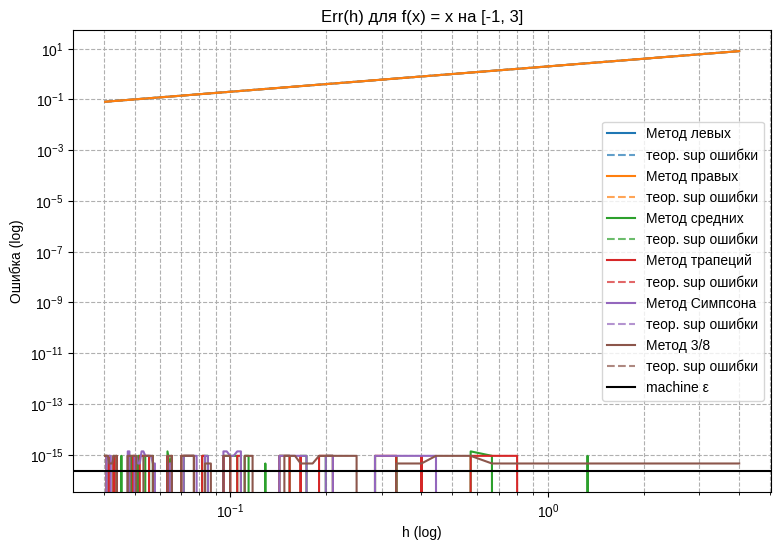

In [28]:
test_h(
  title = "f(x) = x",
  f = lambda x: x,
  F = lambda x: x**2/2,
  a = -1,
  b = 3,
  M = {1: 1, 2: 0, 4: 0},
  n_axis = range(1, 100, 1)
)

##### $f(x) = x^2$

Метод симпсона и 3/8 с точностью описывают квадратную функцию. Остальные же просто приближают её линейными.

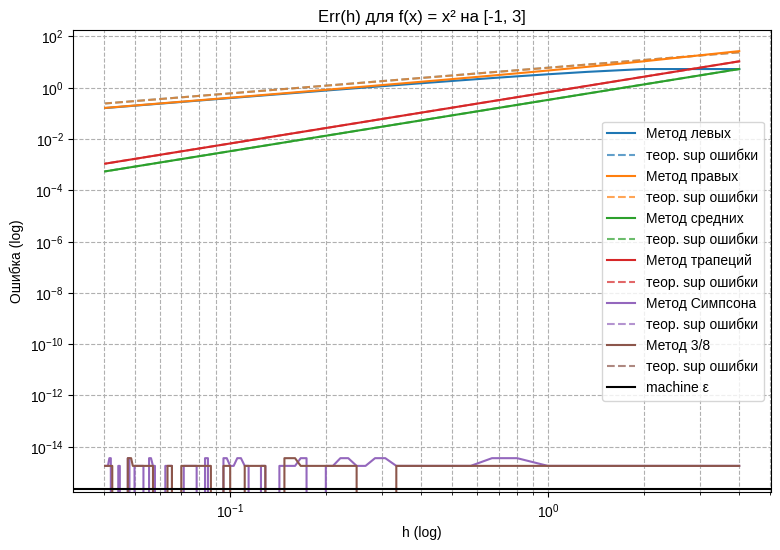

In [29]:
test_h(
  title = "f(x) = x²",
  f = lambda x: x**2,
  F = lambda x: x**3/3,
  a = -1,
  b = 3,
  M = {1: 3, 2: 2, 4: 0},
  n_axis = range(1, 100, 1)
)

##### $f(x) = x^5$

При увеличении степеней погрешность всех методов увеличивается. Из-интересного: график ошибки от h начинает колебаться: то убывает, то остаётся прежней.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8309 (\N{SUPERSCRIPT FIVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


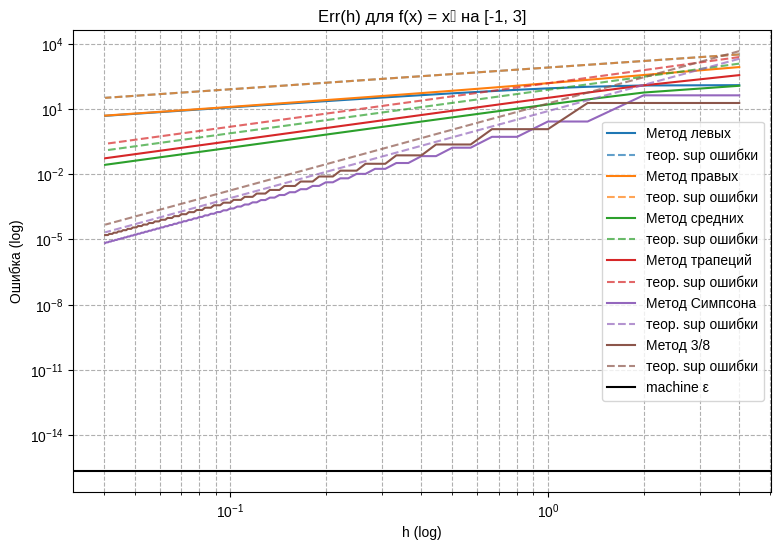

In [30]:
test_h(
  title = "f(x) = x⁵",
  f = lambda x: x**5,
  F = lambda x: x**6/6,
  a = -1,
  b = 3,
  M = {1: 405, 2: 460, 4: 360},
  n_axis = range(1, 100, 1)
)

##### $f(x) = \frac1x$

При отрицательных степенях не происходит ничего интересного, кроме невозможности вычислить интеграл около нуля. Ошибки возрастают при убывании n.

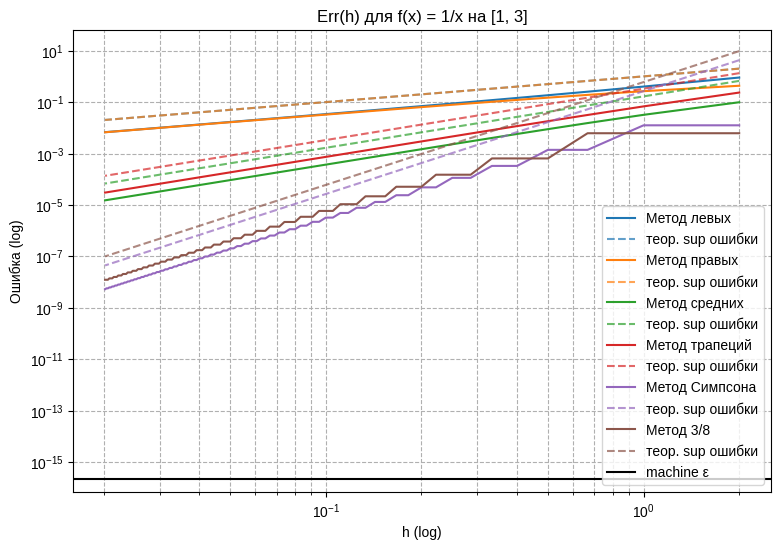

In [31]:
test_h(
  title = "f(x) = 1/x",
  f = lambda x: 1/x,
  F = lambda x: math.log(x),
  a = 1,
  b = 3,
  M = {1: 1, 2: 2, 4: 24},
  n_axis = range(1, 100, 1)
)

##### $f(x) = \frac1{x^2}$

При отрицательных степенях не происходит ничего интересного, кроме невозможности вычислить интеграл около нуля. Ошибки возрастают при убывании n.

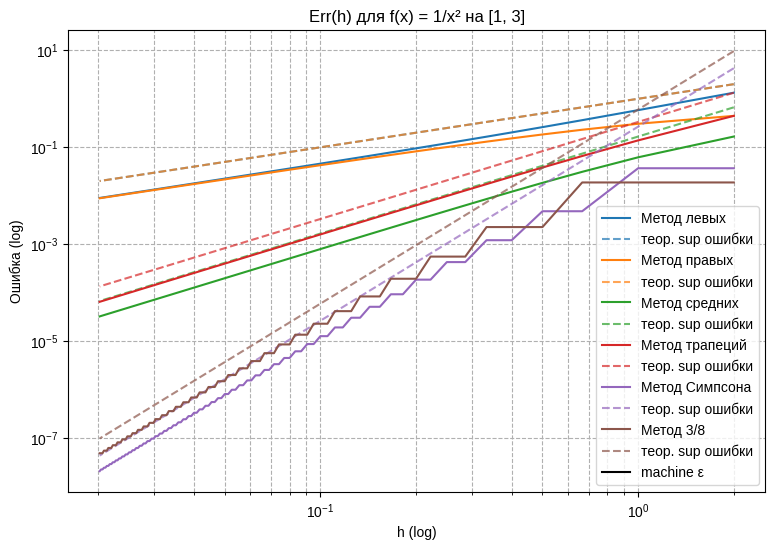

In [32]:
test_h(
  title = "f(x) = 1/x²",
  f = lambda x: x**(-2),
  F = lambda x: x**(-1) / (-1),
  a = 1,
  b = 3,
  M = {1: 1, 2: 2, 4: 24},
  n_axis = range(1, 100, 1)
)

### $f(x) = e^x$

In [33]:
test_simple(
  f = lambda x: math.exp(x),
  F = lambda x: math.exp(x),
  a = -2,
  b = 2,
  n = 100
)

Истинное значение 7.253720815694038
Шаг 0.040
Метод левых:	7.1096135364	(1.98666702%)
Метод правых:	7.3997623690	(2.01333298%)
Метод средних:	7.2532372569	(0.00666636%)
Метод трапеций:	7.2546879527	(0.01333298%)
Метод Симпсона:	7.2537209188	(0.00000142%)
Метод 3/8:	7.2537210301	(0.00000296%)


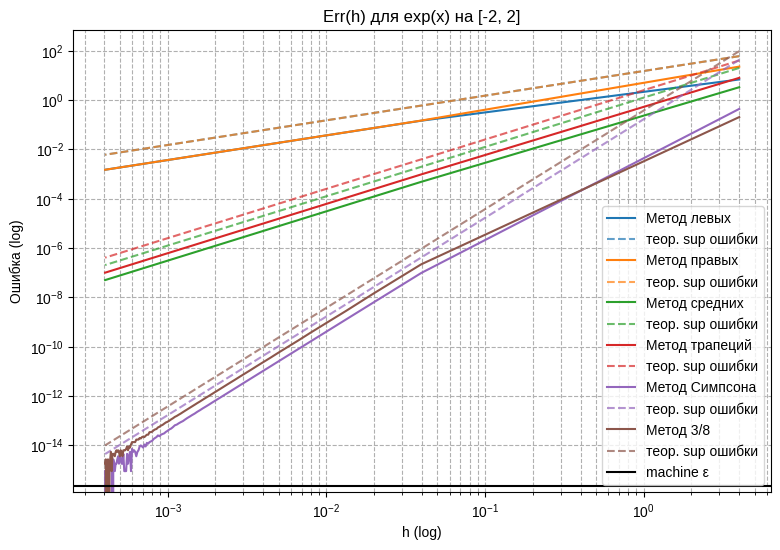

In [34]:
test_h(
  title = "exp(x)",
  f = lambda x: math.exp(x),
  F = lambda x: math.exp(x),
  a = -2,
  b = 2,
  M = {1: math.exp(2), 2: math.exp(2), 4: math.exp(2)},
  n_axis = range(1, 10000, 100)
)

### $f(x) = \sin{x}$

In [35]:
test_simple(
  f = lambda x: math.sin(x),
  F = lambda x: -math.cos(x),
  a = 0,
  b = 1 * math.pi,
  n = 100
)

Истинное значение 2.0
Шаг 0.031
Метод левых:	1.9998355039	(0.00822481%)
Метод правых:	1.9998355039	(0.00822481%)
Метод средних:	2.0000822491	(0.00411245%)
Метод трапеций:	1.9998355039	(0.00822481%)
Метод Симпсона:	2.0000000108	(0.00000054%)
Метод 3/8:	2.0000000225	(0.00000113%)


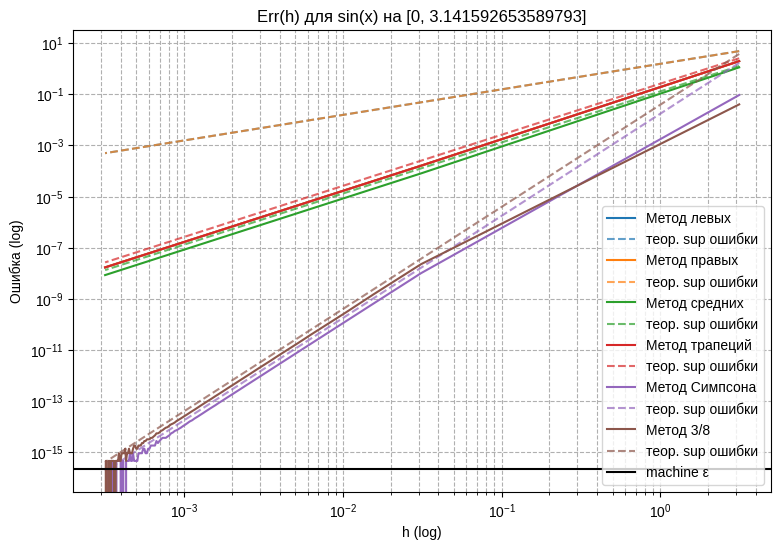

In [36]:
test_h(
  title = "sin(x)",
  f = lambda x: math.sin(x),
  F = lambda x: -math.cos(x),
  a = 0,
  b = math.pi,
  M = {1: 1, 2: 1, 4: 1},
  n_axis = range(1, 10000, 100)
)

Как в синусе, так и в экспоненте ошибка уменьшается, пока не достигает значений, недоступных из-за машинной точности. Реальная ошибка не превосходит оценку сверху.

### Метод Монте-Карло

In [37]:
# Для воспроизводимости результата
np.random.seed(0)

In [38]:
def integrate_monte_carlo(f: ScalarFunc, a: float, b: float, n: int) -> float:
  """ Вычисляет интеграл методом Монте-Карло """
  xs = np.random.uniform(a, b, n)
  return (b - a) * np.average(f(xs))

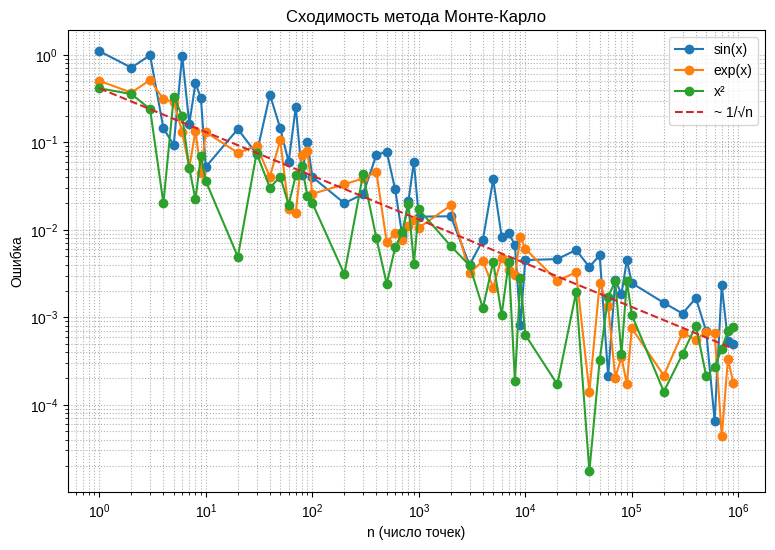

In [39]:
Test = namedtuple('Test' , 'name func a b F')
tests = [
    ("sin(x)", lambda x: np.sin(x), 0, math.pi, lambda x: -np.cos(x)),
    ("exp(x)", lambda x: np.exp(x), 0, 1,       lambda x: np.exp(x)),
    ("x²"    , lambda x: x**2,      0, 1,       lambda x: x**3/3)
]
# Количество точек
n_values = []
for i in range(6):
  n_values.extend(list(range(10**i, 10**(i+1), 10**i)))

# Эксперементы
plt.figure(figsize=(9,6))
for name, f, a, b, F in tests:
    exact = F(b) - F(a)
    errors = []
    for n in n_values:
        estimate = integrate_monte_carlo(f, a, b, n)
        errors.append(abs(estimate - exact))
    plt.plot(n_values, errors, marker="o", label=name)

# Линия сходимости 1/√n
n_ref = np.array(n_values)
err_ref = errors[0] * (n_ref / n_ref[0])**(-0.5)
plt.plot(n_ref, err_ref, linestyle="--", label="~ 1/√n")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("n (число точек)")
plt.ylabel("Ошибка")
plt.title("Сходимость метода Монте-Карло")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.show()

Ошибка в методе ожидаемо уменьшается согласно линии сходимости $\frac1{\sqrt{n}}$.

# Заключение

В ходе выполнения лабораторной работы были реализованы и исследованы основные численные методы математического анализа, включая интерполяцию, численное дифференцирование и интегрирование, а также метод Монте-Карло для приближённого вычисления интегралов.

На основании проведённых вычислительных экспериментов можно сделать следующие выводы:

- увеличение числа узлов интерполяции в целом повышает точность, однако для полиномиальной интерполяции на равномерной сетке возможно ухудшение аппроксимации из-за эффекта Рунге,

- сплайн-интерполяция является более устойчивой и надёжной по сравнению с полиномиальной, а выбор граничных условий существенно влияет на точность результата,

- при численном дифференцировании уменьшение шага сетки снижает погрешность, но слишком малый шаг может приводить к накоплению ошибок округления,

- методы численного интегрирования более высоких порядков обеспечивают лучшую точность при гладких функциях, однако требуют большего числа вычислений,

- метод Монте-Карло характеризуется медленной сходимостью, но эффективен для интегрирования при сложной области интегрирования.